Following from CONUS_setup, which compiles the national data for modelling, this notebook imports the master dataset and starts the actual modelling.
- Start by checking just FL to ensure we get the same results as when we were analysing just FL. Then we can run the same code on the full CONUS dataset and see how it performs.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut

master_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"

event_FL_df = pd.read_parquet(master_path)

event_FL_df["CountyFIPS"] = event_FL_df["CountyFIPS"].astype(str).str.zfill(5)
event_FL_df["event_start"] = pd.to_datetime(event_FL_df["event_start"])

# Florida replication subset from the CONUS master table
event_FL_df = event_FL_df[event_FL_df["CountyFIPS"].str.startswith("12")].copy()

# Make sure the target column name matches the old notebook convention
if "t90" not in event_FL_df.columns and "t90_lastcross" in event_FL_df.columns:
    event_FL_df["t90"] = event_FL_df["t90_lastcross"]

print("Florida subset shape:", event_FL_df.shape)
print("Columns:")
print(event_FL_df.columns.tolist())
print(event_FL_df.head().to_string(index=False))

Florida subset shape: (90, 42)
Columns:
['event_id', 'storm', 'CountyFIPS', 'county', 'event_start', 'duration_hours', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'n_periods', 'integral', 'pop_hours_supply_lost', 'duration_days', 'year', 'month', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'weather_hours_available', 'weather_hours_used', 'matched_ibtracs_storm', 'min_dist_to_storm_km', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 'storm_max_wind_center_in_conus_mps', 'storm_max_wind_near_conus_mps', 't90_lastcross', 'censored_lastcross', 'crossing_time_lastcross', 't50', 't50_censored', 'peak_outage_clean_t50', 'threshold_used_t50', 'crossing_time_t50', 'max_outage_raw', 'hours_above_thresh_raw', 'n_ts_points', 'is_valid', 't90', 't90_censored', 'peak_outage_clean']
                 event_id         storm CountyFIPS    county         event_start  duration_hours  county_pop  pre_outage_tracked_customers  days_since_d

In [39]:
# -----------------------
# RF_v4 feature set
# -----------------------

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

target_col = "t90"
group_col = "storm"

X = event_FL_df[features_v4].copy()
y = event_FL_df[target_col].copy()
groups = event_FL_df[group_col].copy()

print("Missing values by feature:")
print(X.isna().sum())

print("\nFeature preview:")
print(X.head())

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

model_v4 = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42
    ))
])


logo = LeaveOneGroupOut()

def evaluate_logo_global(model, X, y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)

    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_v4_fl, fold_v4_fl, mae_v4_fl, rmse_v4_fl = evaluate_logo_global(model_v4, X, y, groups)

print("RF_v4-inspired global metrics:")
print("Global MAE:", mae_v4_fl)
print("Global RMSE:", rmse_v4_fl)

print("\nPer-storm diagnostics:")
print(fold_v4_fl.sort_values("mae_diagnostic_per_storm", ascending=False))

Missing values by feature:
max_gust                           0
mean_gust_7d                       0
total_precip_7d                    0
pressure_min_7d                    0
county_pop                         0
min_dist_to_storm_km               0
storm_max_wind_near_conus_mps      0
county_gdp_real_2017_dollars       0
county_gdp_real_2017_per_capita    0
dtype: int64

Feature preview:
     max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  county_pop  \
1   12.601287      7.421799        67.413998      1009.864246       45260   
21  27.279316     12.005697        92.750718       995.318712       12498   
22  33.241034      9.333728       153.916280       982.833530        7786   
23  25.291777     14.104932        89.230104       996.010565       13464   
24  33.169058      9.553964       145.733609       976.919507       45260   

    min_dist_to_storm_km  storm_max_wind_near_conus_mps  \
1              31.525385                       25.72220   
21            169.092475    

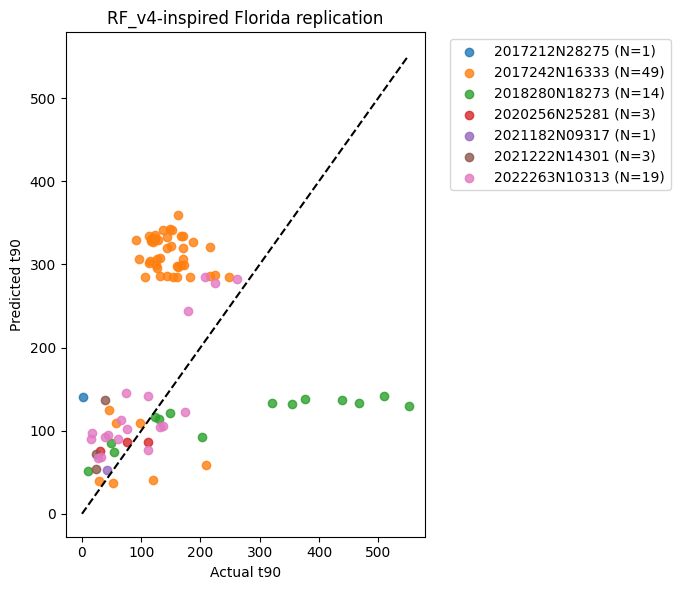

In [ ]:
def plot_scatter_by_storm(
    preds,
    data_df,
    title,
    target_col="t90",
    group_col="storm",
    max_legend_storms=15,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    preds = np.asarray(preds)
    if len(preds) != len(data_df):
        raise ValueError(
            f"Length mismatch: preds has length {len(preds)} but data_df has length {len(data_df)}"
        )

    plot_df = data_df[[group_col, target_col]].copy()
    plot_df["pred"] = preds

    # Keep the old appearance order when there are only a few storms.
    storms_in_order = list(plot_df[group_col].dropna().unique())
    storm_counts = plot_df[group_col].value_counts(dropna=False)

    # Use the default matplotlib color cycle so the style stays familiar.
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    plt.figure(figsize=(7, 6))

    if len(storms_in_order) <= max_legend_storms:
        # Original behavior: one color per storm, in appearance order.
        for i, storm in enumerate(storms_in_order):
            s = plot_df[group_col] == storm
            plt.scatter(
                plot_df.loc[s, target_col],
                plot_df.loc[s, "pred"],
                label=f"{storm} (N={int(s.sum())})",
                alpha=0.8,
                color=colors[i % len(colors)],
            )
    else:
        # Top 10 storms by number of events, then one "Other" category.
        top_storms = storm_counts.head(max_legend_storms).index.tolist()
        other_mask = ~plot_df[group_col].isin(top_storms)

        for i, storm in enumerate(top_storms):
            s = plot_df[group_col] == storm
            plt.scatter(
                plot_df.loc[s, target_col],
                plot_df.loc[s, "pred"],
                label=f"{storm} (N={int(s.sum())})",
                alpha=0.8,
                color=colors[i % len(colors)],
            )

        if other_mask.any():
            plt.scatter(
                plot_df.loc[other_mask, target_col],
                plot_df.loc[other_mask, "pred"],
                label=f"Other (N={int(other_mask.sum())})",
                alpha=0.5,
                color="gray",
            )

    m = max(plot_df[target_col].max(), np.nanmax(plot_df["pred"]))
    plt.plot([0, m], [0, m], "--", color="black")

    plt.xlabel(f"Actual {target_col}")
    plt.ylabel(f"Predicted {target_col}")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_scatter_by_storm(pred_v4_fl, event_FL_df, "RF_v4-inspired Florida replication")

Investigating missing events:

In [41]:
print(event_FL_df.shape)
print(event_FL_df[event_FL_df["CountyFIPS"].str.startswith("12")].shape)

(90, 42)
(90, 42)


Investigating why RF_v4 gives slightly different results than the above

In [42]:
# --- Load and normalize the old RF_v4 table and the current FL replication table ---

import pandas as pd
import numpy as np

rf_v4_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v4_gdp.csv"

rf_v4_df = pd.read_csv(rf_v4_path)

# Standardize key fields
rf_v4_df["CountyFIPS"] = rf_v4_df["CountyFIPS"].astype(str).str.zfill(5)
rf_v4_df["event_start"] = pd.to_datetime(rf_v4_df["event_start"], errors="coerce")

event_FL_df = event_FL_df.copy()
event_FL_df["CountyFIPS"] = event_FL_df["CountyFIPS"].astype(str).str.zfill(5)
event_FL_df["event_start"] = pd.to_datetime(event_FL_df["event_start"], errors="coerce")

# Use CountyFIPS + event_start as the comparison key, since event_id conventions differ
rf_v4_df["compare_key"] = (
    rf_v4_df["CountyFIPS"].astype(str) + "_" +
    rf_v4_df["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

event_FL_df["compare_key"] = (
    event_FL_df["CountyFIPS"].astype(str) + "_" +
    event_FL_df["event_start"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

print("Loaded RF_v4 shape:", rf_v4_df.shape)
print("Loaded current FL shape:", event_FL_df.shape)

print("\nRF_v4 columns:")
print(rf_v4_df.columns.tolist())

print("\nCurrent FL columns:")
print(event_FL_df.columns.tolist())

print("\nRF_v4 compare keys head:")
print(rf_v4_df[["event_id", "CountyFIPS", "event_start", "compare_key"]].head().to_string(index=False))

print("\nCurrent FL compare keys head:")
print(event_FL_df[["event_id", "CountyFIPS", "event_start", "compare_key"]].head().to_string(index=False))

Loaded RF_v4 shape: (90, 20)
Loaded current FL shape: (90, 43)

RF_v4 columns:
['event_id', 'storm', 'CountyFIPS', 't90', 't90_censored', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'max_customers_tracked', 'county_pop', 'event_start', 'min_dist_to_storm_km', 'matched_ibtracs_storm', 'storm_max_wind_center_in_conus_mps', 'storm_max_wind_near_conus_mps', 'year', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 'compare_key']

Current FL columns:
['event_id', 'storm', 'CountyFIPS', 'county', 'event_start', 'duration_hours', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'n_periods', 'integral', 'pop_hours_supply_lost', 'duration_days', 'year', 'month', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'weather_hours_available', 'weather_hours_used', 'matched_ibtracs_storm', 'min_dist_to_storm_km', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 'storm_max_wind_center_in_conus_mps', 'storm_m

In [43]:
# --- Compare old RF_v4 table vs current FL replication table using CountyFIPS + event_start ---

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

target_cols = ["t90"]

old_cols = ["compare_key"] + [c for c in features_v4 + target_cols if c in rf_v4_df.columns]
new_cols = ["compare_key"] + [c for c in features_v4 + target_cols if c in event_FL_df.columns]

merged = event_FL_df[new_cols].merge(
    rf_v4_df[old_cols],
    on="compare_key",
    how="outer",
    suffixes=("_new", "_old"),
    indicator=True
)

print("Row set comparison:")
print(merged["_merge"].value_counts())

only_new = merged.loc[merged["_merge"] == "left_only", ["compare_key"]]
only_old = merged.loc[merged["_merge"] == "right_only", ["compare_key"]]

print("\nRows only in current FL table:")
print(only_new.to_string(index=False))

print("\nRows only in old RF_v4 table:")
print(only_old.to_string(index=False))

shared = merged.loc[merged["_merge"] == "both"].copy()
print("\nShared rows:", len(shared))

# Compare features on shared rows
compare_rows = []
for feat in features_v4 + target_cols:
    new_col = f"{feat}_new"
    old_col = f"{feat}_old"

    if new_col not in shared.columns or old_col not in shared.columns:
        continue

    a = shared[new_col]
    b = shared[old_col]

    same = (a.isna() & b.isna()) | (a.eq(b))
    exact_match_rate = float(same.mean())

    if pd.api.types.is_numeric_dtype(a) and pd.api.types.is_numeric_dtype(b):
        diff = (a - b).abs()
        mean_abs_diff = float(diff.mean())
        max_abs_diff = float(diff.max())
    else:
        mean_abs_diff = np.nan
        max_abs_diff = np.nan

    compare_rows.append({
        "feature": feat,
        "exact_match_rate": exact_match_rate,
        "mean_abs_diff": mean_abs_diff,
        "max_abs_diff": max_abs_diff,
        "n_missing_new": int(a.isna().sum()),
        "n_missing_old": int(b.isna().sum()),
    })

compare_df = pd.DataFrame(compare_rows)

print("\nFeature comparison on shared rows:")
print(compare_df.to_string(index=False))

# Show the rows that differ most overall
if len(shared) > 0:
    diff_score = np.zeros(len(shared), dtype=float)

    for feat in features_v4 + target_cols:
        nc = f"{feat}_new"
        oc = f"{feat}_old"
        if nc in shared.columns and oc in shared.columns:
            if pd.api.types.is_numeric_dtype(shared[nc]) and pd.api.types.is_numeric_dtype(shared[oc]):
                diff_score += (shared[nc] - shared[oc]).abs().fillna(0).to_numpy()

    shared = shared.assign(total_abs_diff=diff_score)

    print("\nTop 10 most different shared rows:")
    print(
        shared.sort_values("total_abs_diff", ascending=False)[
            ["compare_key", "total_abs_diff"]
        ].head(10).to_string(index=False)
    )

Row set comparison:
_merge
both          90
left_only      0
right_only     0
Name: count, dtype: int64

Rows only in current FL table:
Empty DataFrame
Columns: [compare_key]
Index: []

Rows only in old RF_v4 table:
Empty DataFrame
Columns: [compare_key]
Index: []

Shared rows: 90

Feature comparison on shared rows:
                        feature  exact_match_rate  mean_abs_diff  max_abs_diff  n_missing_new  n_missing_old
                       max_gust          0.966667   1.184238e-16  3.552714e-15              0              0
                   mean_gust_7d          0.855556   2.565849e-16  1.776357e-15              0              0
                total_precip_7d          0.833333   4.519841e-15  5.684342e-14              0              0
                pressure_min_7d          1.000000   0.000000e+00  0.000000e+00              0              0
                     county_pop          1.000000   0.000000e+00  0.000000e+00              0              0
           min_dist_to_storm

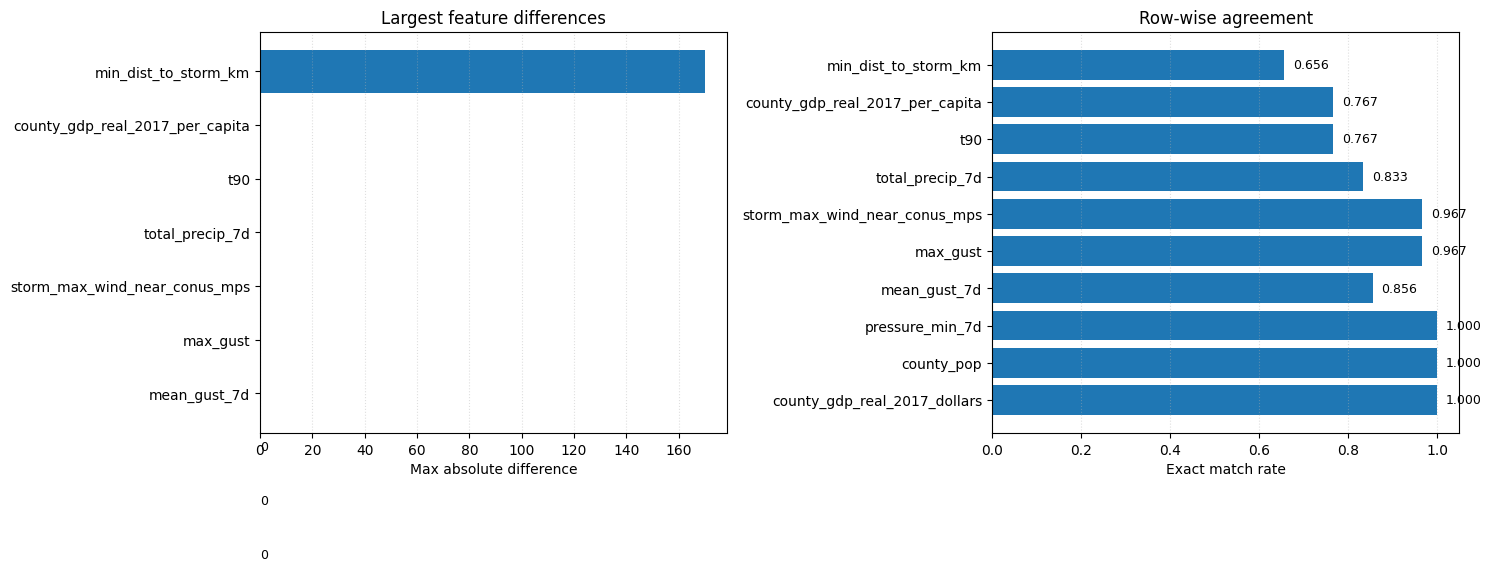

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Work on a copy so we can safely order and handle zeros
plot_df = compare_df.copy()

# Order by max absolute difference, largest first
plot_df = plot_df.sort_values("max_abs_diff", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel 1: max absolute difference on a log scale ---
vals = plot_df["max_abs_diff"].to_numpy(dtype=float)
vals_plot = np.where(vals > 0, vals, np.nan)

axes[0].barh(plot_df["feature"], vals_plot)
# axes[0].set_xscale("log")
axes[0].invert_yaxis()
# axes[0].set_xlabel("Max absolute difference (log scale)")
axes[0].set_xlabel("Max absolute difference")

axes[0].set_title("Largest feature differences")
axes[0].grid(True, axis="x", which="both", linestyle=":", alpha=0.4)

# Add labels for exact zeros so they are visible
for i, v in enumerate(vals):
    if v == 0:
        axes[0].text(1e-18, i, "0", va="center", ha="left", fontsize=9)

# --- Panel 2: exact match rate ---
axes[1].barh(plot_df["feature"], plot_df["exact_match_rate"])
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel("Exact match rate")
axes[1].set_title("Row-wise agreement")
axes[1].grid(True, axis="x", linestyle=":", alpha=0.4)

for i, v in enumerate(plot_df["exact_match_rate"]):
    axes[1].text(min(v + 0.02, 1.02), i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

So theres somewhat of a difference for min distance; up to 12 km?

------------------ **FULL CONUS RF:** -------------------

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut

# Load the CONUS master table
master_candidates = [
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.parquet",
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_ibtracs.parquet",
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_with_gdp.parquet",
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master.parquet",
]

master_path = next((p for p in master_candidates if __import__("os").path.exists(p)), None)
if master_path is None:
    raise FileNotFoundError("No CONUS master parquet found in the expected locations.")

event_df = pd.read_parquet(master_path)
event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)
event_df["event_start"] = pd.to_datetime(event_df["event_start"])

if "t90" not in event_df.columns and "t90_lastcross" in event_df.columns:
    event_df["t90"] = event_df["t90_lastcross"]

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

missing_features = [c for c in features_v4 if c not in event_df.columns]
if missing_features:
    raise KeyError(f"Missing expected features: {missing_features}")

event_df = event_df.dropna(subset=["t90"]).copy()

X = event_df[features_v4].copy()
y = event_df["t90"].copy()
groups = event_df["storm"].copy()

print("Using master file:", master_path)
print("Event shape:", event_df.shape)
print("Missing values by feature:")
print(X.isna().sum())

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

model_v4 = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42
    ))
])

logo = LeaveOneGroupOut()

def evaluate_logo_global(model, X, y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)
    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_v4_conus, fold_v4_conus, mae_v4_conus, rmse_v4_conus = evaluate_logo_global(model_v4, X, y, groups)

print("\nRF global metrics:")
print("Global MAE:", mae_v4)
print("Global RMSE:", rmse_v4)

print("\nPer-storm diagnostics:")
print(fold_v4.sort_values("mae_diagnostic_per_storm", ascending=False))

Using master file: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.parquet
Event shape: (913, 42)
Missing values by feature:
max_gust                            0
mean_gust_7d                        0
total_precip_7d                     0
pressure_min_7d                     0
county_pop                          0
min_dist_to_storm_km                0
storm_max_wind_near_conus_mps       0
county_gdp_real_2017_dollars       18
county_gdp_real_2017_per_capita    18
dtype: int64

RF global metrics:
Global MAE: 47.21870831353867
Global RMSE: 78.99450095493896

Per-storm diagnostics:
    fold          storm    n  mae_diagnostic_per_storm  \
2      3  2017228N14314   19                103.701455   
24    25  2021239N17281   39                 97.432967   
3      4  2017242N16333  127                 92.511007   
6      7  2018242N13343   40                 75.070760   
7      8  2018280N18273  152                 62.142949   
9   

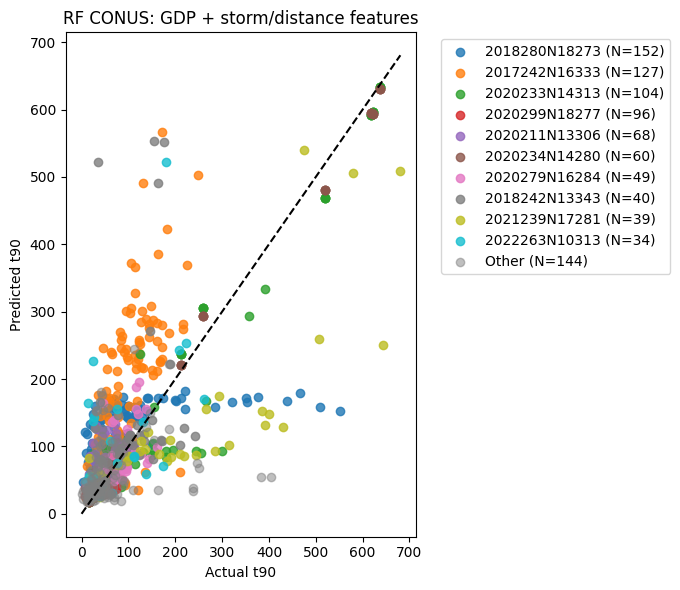

In [46]:
plot_scatter_by_storm(pred_v4_conus, event_df, "RF CONUS: GDP + storm/distance features")

CONUS LOSO mean baseline:
Global MAE: 78.87805805789709
Global RMSE: 127.65166740772119

Per-storm diagnostics:
    fold          storm    n  mae_diagnostic_per_storm  \
16    17  2020234N14280   60                184.047233   
24    25  2021239N17281   39                157.721072   
15    16  2020233N14313  104                136.613355   
2      3  2017228N14314   19                 96.518642   
1      2  2017212N28275    1                 95.341718   
10    11  2019291N22264    1                 93.464174   
0      1  2017171N24271    1                 84.559252   
4      5  2017277N11279    4                 70.911752   
20    21  2021169N23268    1                 69.809807   
5      6  2018146N19273    8                 69.211839   
11    12  2019299N25265   20                 68.308055   
27    28  2022263N10313   34                 67.530148   
21    22  2021182N09317    2                 66.968126   
7      8  2018280N18273  152                 66.816175   
22    23  2021222N

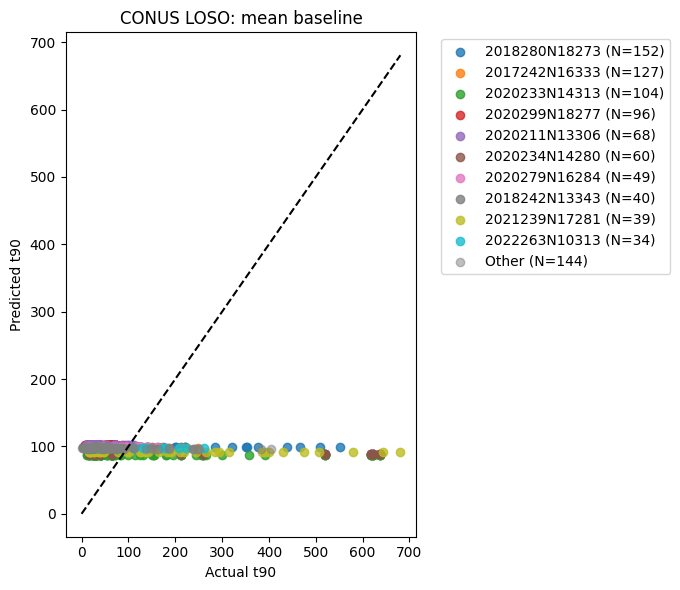

In [47]:
# --- CONUS LOSO mean baseline ---

import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

logo = LeaveOneGroupOut()

def evaluate_mean_logo(y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(np.zeros(len(y)), y, groups), start=1):
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        y_pred = np.full(len(test_idx), float(y_train.mean()))
        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)
    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_mean, fold_mean, mae_mean, rmse_mean = evaluate_mean_logo(y, groups)

print("CONUS LOSO mean baseline:")
print("Global MAE:", mae_mean)
print("Global RMSE:", rmse_mean)

print("\nPer-storm diagnostics:")
print(fold_mean.sort_values("mae_diagnostic_per_storm", ascending=False))

plot_scatter_by_storm(pred_mean, event_df, "CONUS LOSO: mean baseline")

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Match predictions to the dataframe used to generate them
df_plot = event_df.copy()
y_true = df_plot["t90"].to_numpy()
y_pred = np.asarray(pred_mean)

# Keep only finite pairs
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

y_range = np.max(y_true) - np.min(y_true)
y_mean = np.mean(y_true)
y_std = np.std(y_true, ddof=0)
y_var = np.var(y_true, ddof=0)

nmae_range = mae / y_range if y_range > 0 else np.nan
nmae_mean = mae / y_mean if y_mean > 0 else np.nan
nrmse_std = rmse / y_std if y_std > 0 else np.nan
nmse_var = (rmse ** 2) / y_var if y_var > 0 else np.nan

print("CONUS LOSO mean baseline metrics:")
print(f"MAE:  {mae:.3f} hours")
print(f"RMSE: {rmse:.3f} hours")
print(f"R^2:  {r2:.3f}")
print()
print("Normalized metrics:")
print(f"nMAE / range: {nmae_range:.3f}")
print(f"nMAE / mean:   {nmae_mean:.3f}")
print(f"nRMSE / std:    {nrmse_std:.3f}")
print(f"NMSE / var:     {nmse_var:.3f}")

CONUS LOSO mean baseline metrics:
MAE:  78.878 hours
RMSE: 127.652 hours
R^2:  -0.031

Normalized metrics:
nMAE / range: 0.116
nMAE / mean:   0.812
nRMSE / std:    1.015
NMSE / var:     1.031


CONUS LOSO mean baseline metrics:
MAE:  78.878 hours
RMSE: 127.652 hours
R^2:  -0.031

Normalized metrics:
nMAE / range: 0.116
nMAE / mean:   0.812
nRMSE / std:    1.015
NMSE / var:     1.031


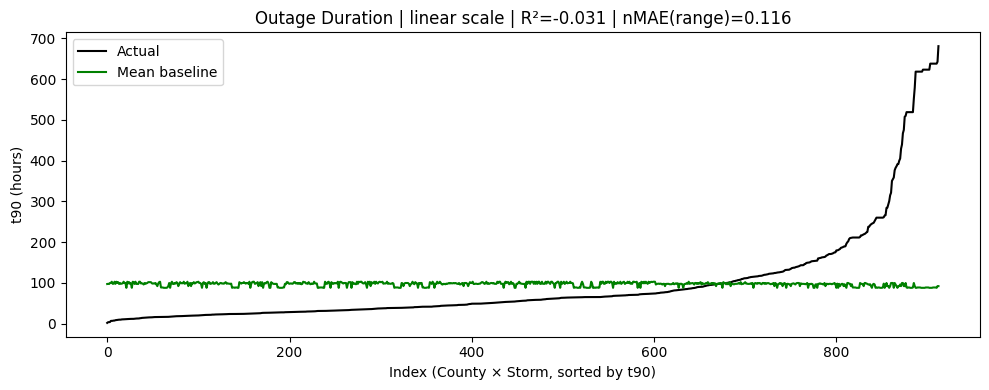

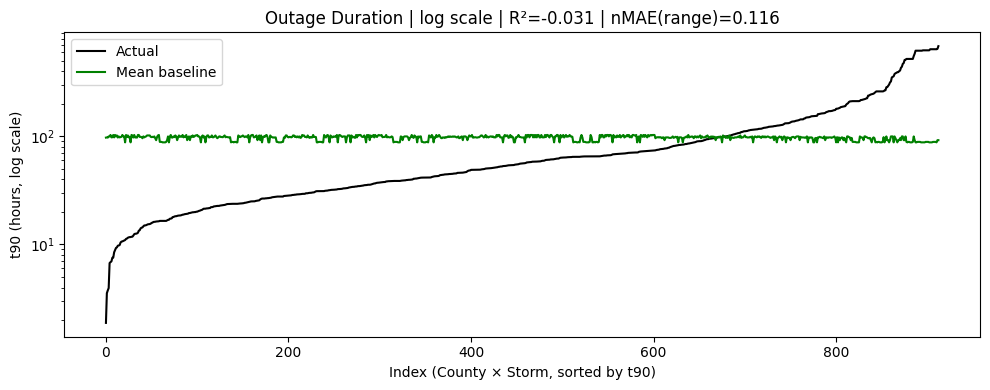

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Match predictions to the dataframe used to generate them
df_plot = event_df.copy()
y_true = df_plot["t90"].to_numpy()
y_pred = np.asarray(pred_mean)

# Keep only finite pairs
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

# Metrics on the original scale
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

y_range = np.max(y_true) - np.min(y_true)
y_mean = np.mean(y_true)
y_std = np.std(y_true, ddof=0)
y_var = np.var(y_true, ddof=0)

nmae_range = mae / y_range if y_range > 0 else np.nan
nmae_mean = mae / y_mean if y_mean > 0 else np.nan
nrmse_std = rmse / y_std if y_std > 0 else np.nan
nmse_var = (rmse ** 2) / y_var if y_var > 0 else np.nan

print("CONUS LOSO mean baseline metrics:")
print(f"MAE:  {mae:.3f} hours")
print(f"RMSE: {rmse:.3f} hours")
print(f"R^2:  {r2:.3f}")
print()
print("Normalized metrics:")
print(f"nMAE / range: {nmae_range:.3f}")
print(f"nMAE / mean:   {nmae_mean:.3f}")
print(f"nRMSE / std:    {nrmse_std:.3f}")
print(f"NMSE / var:     {nmse_var:.3f}")

# Sort by actual t90
order = np.argsort(y_true)
y_sorted = y_true[order]
pred_sorted = y_pred[order]
x = np.arange(len(y_sorted))

# Linear scale
plt.figure(figsize=(10, 4))
plt.plot(x, y_sorted, color="black", label="Actual")
plt.plot(x, pred_sorted, color="green", label="Mean baseline")

plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("t90 (hours)")
plt.title(f"Outage Duration | linear scale | R²={r2:.3f} | nMAE(range)={nmae_range:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

# Log scale
eps = 1e-6
y_sorted_log = np.clip(y_sorted, eps, None)
pred_sorted_log = np.clip(pred_sorted, eps, None)

plt.figure(figsize=(10, 4))
plt.plot(x, y_sorted_log, color="black", label="Actual")
plt.plot(x, pred_sorted_log, color="green", label="Mean baseline")

plt.yscale("log")
plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("t90 (hours, log scale)")
plt.title(f"Outage Duration | log scale | R²={r2:.3f} | nMAE(range)={nmae_range:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

RF beats Mean!

**Let's now try tuning RF:**

In [83]:
# --- CONUS LOSO tuned RF with progress bar ---

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

X = event_df[features_v4].copy()
y = event_df["t90"].copy()
groups = event_df["storm"].copy()

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

logo = LeaveOneGroupOut()
splits = list(logo.split(X, y, groups))

rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(random_state=42))
])

param_grid = {
    # "rf__n_estimators": [200, 400],
    # "rf__max_depth": [None, 10, 20],
    # "rf__min_samples_leaf": [1, 3, 5],
    # "rf__max_features": [0.2, 0.5, 1.0],

    # "rf__n_estimators": [200, 400],
    # "rf__max_depth": [10, 20],
    # "rf__min_samples_leaf": [1, 3, 5],
    # "rf__max_features": [0.2, 0.5, 1.0],

    "rf__n_estimators": [200, 400],
    "rf__max_depth": [10, 20, 30],
    "rf__min_samples_leaf": [1, 2, 3],
    "rf__max_features": [0.1, 0.3, 0.5],

}

grid_list = list(ParameterGrid(param_grid))
print(f"Total parameter combinations: {len(grid_list)}")

best_mae = np.inf
best_params = None
best_preds = None
best_fold_df = None

search_rows = []

for params in tqdm(grid_list, desc="RF grid search"):
    fold_preds = np.full(len(y), np.nan)
    fold_rows = []
    fold_maes = []

    for fold_i, (train_idx, test_idx) in enumerate(splits, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = rf_pipe.set_params(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_preds[test_idx] = y_pred

        fold_mae = mean_absolute_error(y_test, y_pred)
        fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_maes.append(fold_mae)

        fold_rows.append({
            "fold": fold_i,
            "storm": groups.iloc[test_idx].iloc[0],
            "n": len(test_idx),
            "mae_diagnostic_per_storm": fold_mae,
            "rmse_diagnostic_per_storm": fold_rmse,
        })

    global_mae = mean_absolute_error(y, fold_preds)

    search_rows.append({
        **params,
        "cv_global_mae": global_mae,
        "cv_fold_mae_mean": float(np.mean(fold_maes)),
    })

    if global_mae < best_mae:
        best_mae = global_mae
        best_params = params.copy()
        best_preds = fold_preds.copy()
        best_fold_df = pd.DataFrame(fold_rows)

rf_search_df = pd.DataFrame(search_rows).sort_values("cv_global_mae").reset_index(drop=True)

print("\nBest RF params:")
print(best_params)
print("Best CV global MAE:", best_mae)

best_rf = rf_pipe.set_params(**best_params)
pred_rf_tuned, fold_rf_tuned, mae_rf_tuned, rmse_rf_tuned = evaluate_logo_global(
    best_rf, X, y, groups
)

print("\nTuned RF CONUS LOSO:")
print("Global MAE:", mae_rf_tuned)
print("Global RMSE:", rmse_rf_tuned)

print("\nTop 10 parameter sets:")
print(rf_search_df.head(10).to_string(index=False))

print("\nPer-storm diagnostics:")
print(fold_rf_tuned.sort_values("mae_diagnostic_per_storm", ascending=False))


Total parameter combinations: 54


RF grid search: 100%|██████████| 54/54 [10:21<00:00, 11.52s/it]



Best RF params:
{'rf__max_depth': 20, 'rf__max_features': 0.1, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 400}
Best CV global MAE: 36.41600109361899

Tuned RF CONUS LOSO:
Global MAE: 36.41600109361899
Global RMSE: 62.36942042758291

Top 10 parameter sets:
 rf__max_depth  rf__max_features  rf__min_samples_leaf  rf__n_estimators  cv_global_mae  cv_fold_mae_mean
            20               0.1                     1               400      36.416001         29.785407
            30               0.1                     1               400      36.796459         29.908227
            20               0.1                     1               200      36.967731         30.532189
            10               0.1                     1               400      37.387827         31.206288
            30               0.1                     1               200      37.538925         30.841149
            10               0.3                     1               400      37.670155         30.2911

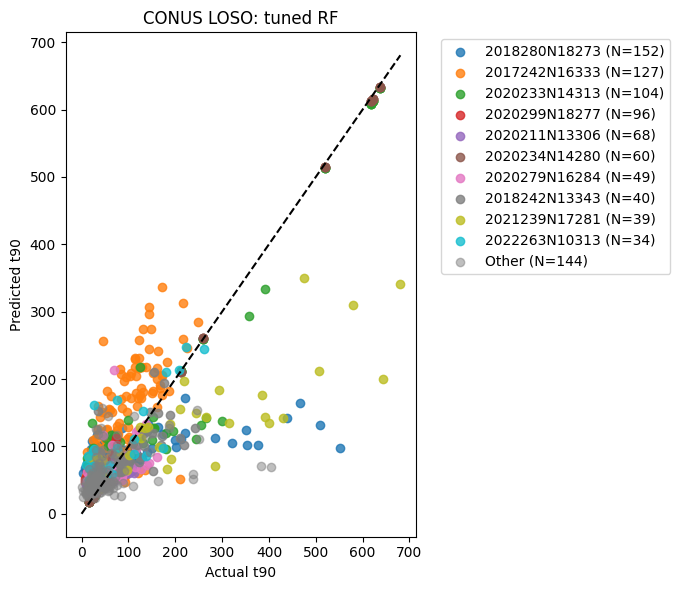

In [84]:
plot_scatter_by_storm(pred_rf_tuned, event_df, "CONUS LOSO: tuned RF")

Tuned RF CONUS R^2: 0.7539153658533576


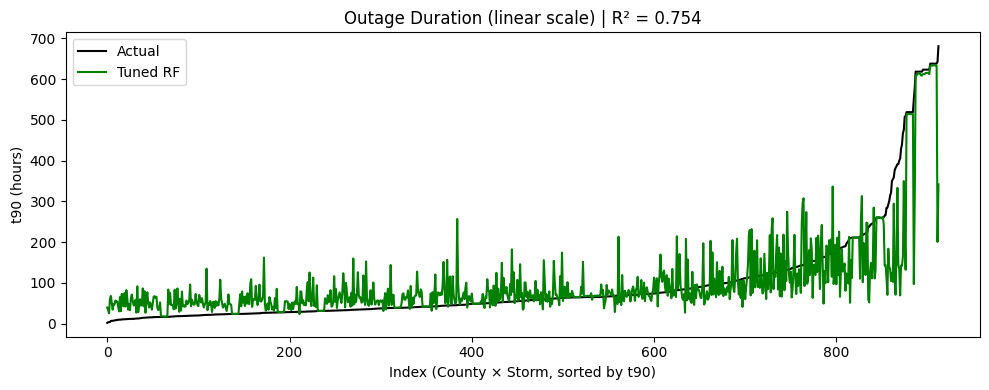

In [85]:
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Match predictions to the dataframe actually used to generate them
df_plot = event_df.copy()
y_true = df_plot["t90"].to_numpy()
y_pred = np.asarray(pred_rf_tuned)

# Drop any rows with missing target or prediction
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

# R^2
r2 = r2_score(y_true, y_pred)
print("Tuned RF CONUS R^2:", r2)

# Sort by actual t90
order = np.argsort(y_true)
y_sorted = y_true[order]
pred_sorted = y_pred[order]
x = np.arange(len(y_sorted))

plt.figure(figsize=(10, 4))
plt.plot(x, y_sorted, color="black", label="Actual")
plt.plot(x, pred_sorted, color="green", label="Tuned RF")

plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("t90 (hours)")
plt.title(f"Outage Duration (linear scale) | R² = {r2:.3f}")
plt.legend()

plt.tight_layout()
plt.show()

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Match predictions to the dataframe used to generate them
df_plot = event_df.copy()
y_true = df_plot["t90"].to_numpy()
y_pred = np.asarray(pred_rf_tuned)

# Keep only finite pairs
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

y_range = np.max(y_true) - np.min(y_true)
y_mean = np.mean(y_true)
y_std = np.std(y_true, ddof=0)
y_iqr = np.percentile(y_true, 75) - np.percentile(y_true, 25)
y_var = np.var(y_true, ddof=0)

nmae_range = mae / y_range if y_range > 0 else np.nan
nmae_mean = mae / y_mean if y_mean > 0 else np.nan
nrmse_std = rmse / y_std if y_std > 0 else np.nan
nrmse_iqr = rmse / y_iqr if y_iqr > 0 else np.nan
nmse_var = (rmse ** 2) / y_var if y_var > 0 else np.nan

print("Tuned RF CONUS metrics:")
print(f"MAE:  {mae:.3f} hours")
print(f"RMSE: {rmse:.3f} hours")
print(f"R^2:  {r2:.3f}")
print()
print("Normalized metrics:")
print(f"nMAE / range: {nmae_range:.3f}")
print(f"nMAE / mean:   {nmae_mean:.3f}")
print(f"nRMSE / std:    {nrmse_std:.3f}")
print(f"nRMSE / IQR:    {nrmse_iqr:.3f}")
print(f"NMSE / var:     {nmse_var:.3f}")

# Sort by actual t90
order = np.argsort(y_true)
y_sorted = y_true[order]
pred_sorted = y_pred[order]
x = np.arange(len(y_sorted))

# plt.figure(figsize=(10, 4))
# plt.plot(x, y_sorted, color="black", label="Actual")
# plt.plot(x, pred_sorted, color="green", label="Tuned RF")

# plt.xlabel("Index (County × Storm, sorted by t90)")
# plt.ylabel("t90 (hours)")
# plt.title(
#     f"Outage Duration | R²={r2:.3f} | nMAE(range)={nmae_range:.3f} | nRMSE(std)={nrmse_std:.3f}"
# )
# plt.legend()
# plt.tight_layout()
# plt.show()

Tuned RF CONUS metrics:
MAE:  36.416 hours
RMSE: 62.369 hours
R^2:  0.754

Normalized metrics:
nMAE / range: 0.054
nMAE / mean:   0.375
nRMSE / std:    0.496
nRMSE / IQR:    0.878
NMSE / var:     0.246


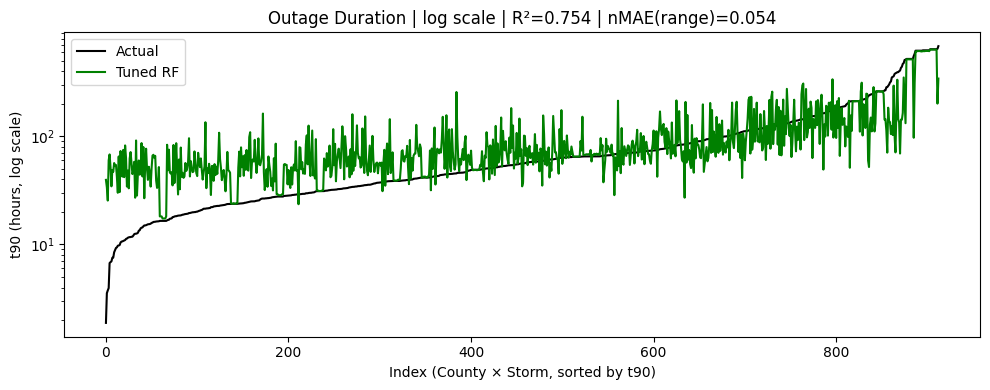

In [87]:
# Log scale: clip at a tiny positive value so the plot is valid if any predictions are <= 0
eps = 1e-6
y_sorted_log = np.clip(y_sorted, eps, None)
pred_sorted_log = np.clip(pred_sorted, eps, None)

plt.figure(figsize=(10, 4))
plt.plot(x, y_sorted_log, color="black", label="Actual")
plt.plot(x, pred_sorted_log, color="green", label="Tuned RF")
plt.yscale("log")
plt.xlabel("Index (County × Storm, sorted by t90)")
plt.ylabel("t90 (hours, log scale)")
plt.title(f"Outage Duration | log scale | R²={r2:.3f} | nMAE(range)={nmae_range:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

RF Hyperparameter tuning effects:


C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\1795560000.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\1795560000.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\1795560000.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\1795560000.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

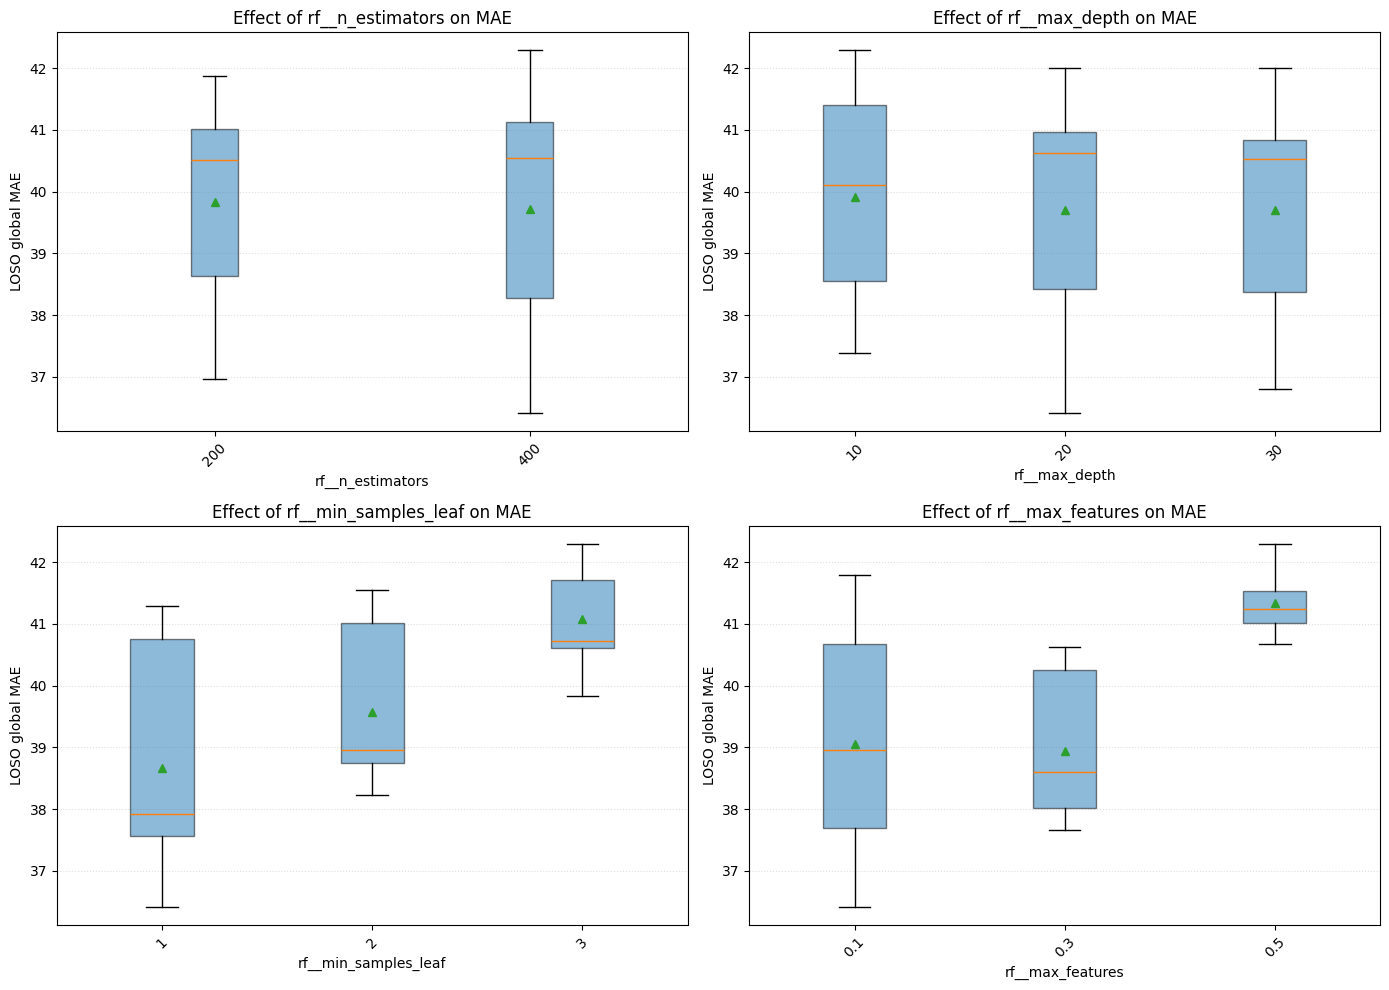

In [88]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rf_hparam_effects(rf_search_df, metric_col="cv_global_mae"):
    """
    Plot hyperparameter effects on LOSO global MAE for tuned RF.
    Uses boxplots for each parameter.
    """
    params = [
        "rf__n_estimators",
        "rf__max_depth",
        "rf__min_samples_leaf",
        "rf__max_features",
    ]

    # Fall back if the requested metric column is named differently
    if metric_col not in rf_search_df.columns:
        if "global_mae" in rf_search_df.columns:
            metric_col = "global_mae"
        elif "cv_global_mae" in rf_search_df.columns:
            metric_col = "cv_global_mae"
        else:
            raise KeyError(
                f"Could not find metric column '{metric_col}', 'global_mae', or 'cv_global_mae' in rf_search_df."
            )

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    def _boxplot_param(ax, df, param):
        dfp = df[[param, metric_col]].dropna().copy()
        values = sorted(dfp[param].unique(), key=lambda x: (str(type(x)), x))
        grouped = [dfp.loc[dfp[param] == v, metric_col].to_numpy() for v in values]

        if len(values) == 1:
            y = grouped[0]
            x = np.zeros(len(y))
            ax.scatter(x, y, alpha=0.8)
            ax.set_xticks([0])
            ax.set_xticklabels([str(values[0])])
        else:
            bp = ax.boxplot(
                grouped,
                labels=[str(v) for v in values],
                showmeans=True,
                patch_artist=True,
            )
            for patch in bp["boxes"]:
                patch.set_alpha(0.5)

        ax.set_xlabel(param)
        ax.set_ylabel("LOSO global MAE")
        ax.grid(True, axis="y", linestyle=":", alpha=0.4)
        ax.tick_params(axis="x", rotation=45)

    for ax, param in zip(axes, params):
        if param not in rf_search_df.columns:
            ax.axis("off")
            continue
        _boxplot_param(ax, rf_search_df, param)
        ax.set_title(f"Effect of {param} on MAE")

    plt.tight_layout()
    plt.show()

# Call it like this:
plot_rf_hparam_effects(rf_search_df)

**NOW FOR MLR, THEN XGB** ---------------------


In [56]:
# --- Helper: ranked actual-vs-predicted plots + metrics (linear and log) ---

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

def report_ranked_predictions(preds, data_df, title, target_col="t90"):
    """
    Print core and normalized metrics, then plot ranked actual-vs-predicted
    on linear and log scales using the same styling.
    """
    y_true = data_df[target_col].to_numpy()
    y_pred = np.asarray(preds)

    if len(y_true) != len(y_pred):
        raise ValueError(
            f"Length mismatch: data_df has {len(y_true)} rows but preds has {len(y_pred)} entries."
        )

    # Keep only finite pairs
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    y_range = np.max(y_true) - np.min(y_true)
    y_mean = np.mean(y_true)
    y_std = np.std(y_true, ddof=0)
    y_var = np.var(y_true, ddof=0)

    nmae_range = mae / y_range if y_range > 0 else np.nan
    nmae_mean = mae / y_mean if y_mean > 0 else np.nan
    nrmse_std = rmse / y_std if y_std > 0 else np.nan
    nmse_var = (rmse ** 2) / y_var if y_var > 0 else np.nan

    print(f"{title} metrics:")
    print(f"MAE:  {mae:.3f} hours")
    print(f"RMSE: {rmse:.3f} hours")
    print(f"R^2:  {r2:.3f}")
    print()
    print("Normalized metrics:")
    print(f"nMAE / range: {nmae_range:.3f}")
    print(f"nMAE / mean:   {nmae_mean:.3f}")
    print(f"nRMSE / std:    {nrmse_std:.3f}")
    print(f"NMSE / var:     {nmse_var:.3f}")

    # Sort by actual t90
    order = np.argsort(y_true)
    y_sorted = y_true[order]
    pred_sorted = y_pred[order]
    x = np.arange(len(y_sorted))

    # Linear scale
    plt.figure(figsize=(10, 4))
    plt.plot(x, y_sorted, color="black", label="Actual")
    plt.plot(x, pred_sorted, color="green", label="Predicted")
    plt.xlabel("Index (County × Storm, sorted by t90)")
    plt.ylabel("t90 (hours)")
    plt.title(f"{title} | linear scale | R²={r2:.3f} | nMAE(range)={nmae_range:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Log scale
    eps = 1e-6
    y_sorted_log = np.clip(y_sorted, eps, None)
    pred_sorted_log = np.clip(pred_sorted, eps, None)

    plt.figure(figsize=(10, 4))
    plt.plot(x, y_sorted_log, color="black", label="Actual")
    plt.plot(x, pred_sorted_log, color="green", label="Predicted")
    plt.yscale("log")
    plt.xlabel("Index (County × Storm, sorted by t90)")
    plt.ylabel("t90 (hours, log scale)")
    plt.title(f"{title} | log scale | R²={r2:.3f} | nMAE(range)={nmae_range:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "nmae_range": nmae_range,
        "nmae_mean": nmae_mean,
        "nrmse_std": nrmse_std,
        "nmse_var": nmse_var,
    }

CONUS LOSO MLR global metrics:
Global MAE: 70.73291589595335
Global RMSE: 108.61532083967319

Per-storm diagnostics:
    fold          storm    n  mae_diagnostic_per_storm  \
13    14  2020205N26272    7                170.255033   
16    17  2020234N14280   60                131.270867   
20    21  2021169N23268    1                108.988239   
3      4  2017242N16333  127                 98.082150   
15    16  2020233N14313  104                 97.297151   
24    25  2021239N17281   39                 89.201977   
6      7  2018242N13343   40                 77.681979   
2      3  2017228N14314   19                 76.709422   
7      8  2018280N18273  152                 71.707751   
9     10  2019236N10314   21                 67.507535   
21    22  2021182N09317    2                 64.011618   
25    26  2021256N21265    8                 60.885395   
5      6  2018146N19273    8                 55.513600   
27    28  2022263N10313   34                 51.758244   
17    18  202

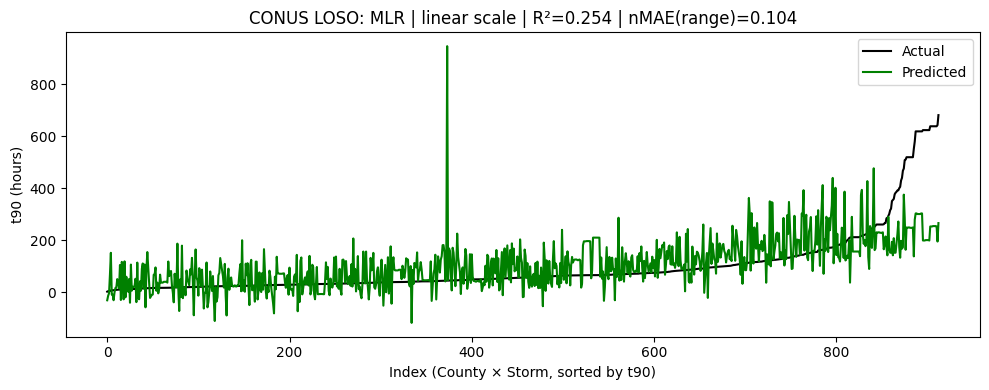

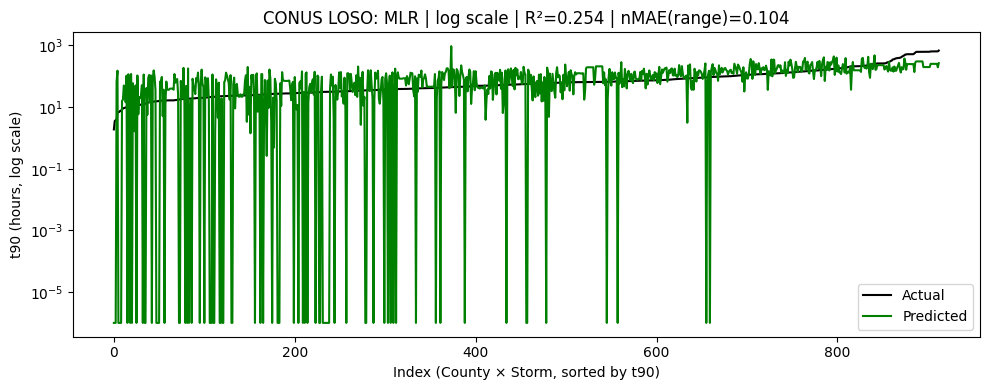

{'mae': 70.73291589595335,
 'rmse': np.float64(108.61532083967319),
 'r2': 0.25368312992175035,
 'nmae_range': np.float64(0.10422214925799124),
 'nmae_mean': np.float64(0.7282857574244854),
 'nrmse_std': np.float64(0.8638963306313147),
 'nmse_var': np.float64(0.7463168700782498)}

In [57]:
# --- MLR for CONUS LOSO, then ranked plots using the helper above ---

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use the same modelling table and features as the tuned RF
features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

X = event_df[features_v4].copy()
y = event_df["t90"].copy()
groups = event_df["storm"].copy()

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

model_mlr = Pipeline([
    ("preprocess", preprocess),
    ("mlr", LinearRegression())
])

logo = LeaveOneGroupOut()

def evaluate_logo_global(model, X, y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)
    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_mlr, fold_mlr, mae_mlr, rmse_mlr = evaluate_logo_global(model_mlr, X, y, groups)

print("CONUS LOSO MLR global metrics:")
print("Global MAE:", mae_mlr)
print("Global RMSE:", rmse_mlr)

print("\nPer-storm diagnostics:")
print(fold_mlr.sort_values("mae_diagnostic_per_storm", ascending=False))

report_ranked_predictions(pred_mlr, event_df, "CONUS LOSO: MLR")

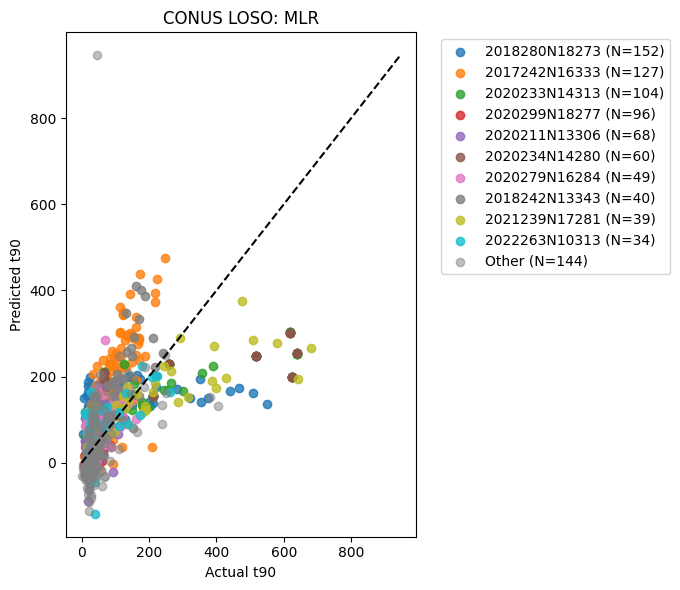

In [58]:
plot_scatter_by_storm(pred_mlr, event_df, "CONUS LOSO: MLR")

**Now, XGB** ~~~~~~~~~~~~~~~~~~~~~~~~~

Missing values by feature:
max_gust                            0
mean_gust_7d                        0
total_precip_7d                     0
pressure_min_7d                     0
county_pop                          0
min_dist_to_storm_km                0
storm_max_wind_near_conus_mps       0
county_gdp_real_2017_dollars       18
county_gdp_real_2017_per_capita    18
dtype: int64

Feature preview:
    max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  county_pop  \
1  20.080783      6.980823        18.274363      1004.653384       22573   
2  12.601287      7.421799        67.413998      1009.864246       45260   
4  23.614344     12.115827       131.434967       994.094691      351674   
5  27.200505     11.924649       176.836706       991.719008        6632   
6  24.878361     12.038954       148.069609       993.947872       69954   

   min_dist_to_storm_km  storm_max_wind_near_conus_mps  \
1             75.666335                       25.72220   
2             31.525385    

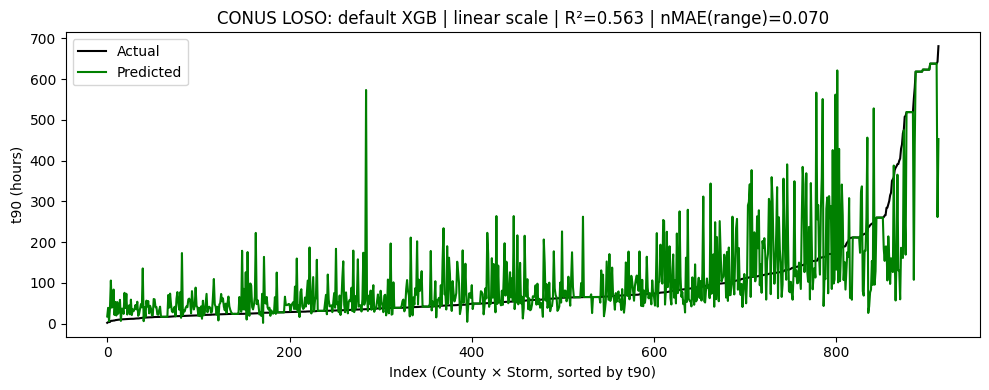

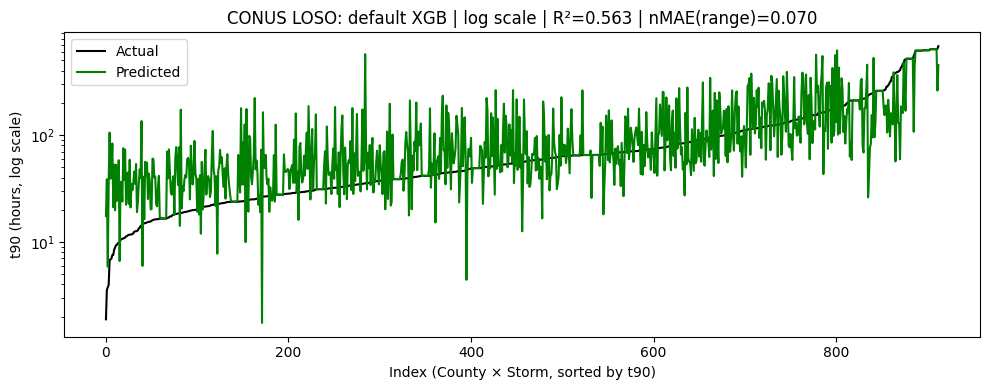

{'mae': 47.84213495500531,
 'rmse': np.float64(83.13429929044503),
 'r2': 0.562778448369617,
 'nmae_range': np.float64(0.07049349043429984),
 'nmae_mean': np.float64(0.49259591593485896),
 'nrmse_std': np.float64(0.6612273070815988),
 'nmse_var': np.float64(0.43722155163038307)}

In [59]:
# --- Default XGB LOSO on CONUS ---

import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

X = event_df[features_v4].copy()
y = event_df["t90"].copy()
groups = event_df["storm"].copy()

print("Missing values by feature:")
print(X.isna().sum())

print("\nFeature preview:")
print(X.head())

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

model_xgb = Pipeline([
    ("preprocess", preprocess),
    ("xgb", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=100,
    ))
])

logo = LeaveOneGroupOut()

def evaluate_logo_global(model, X, y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[test_idx] = y_pred

        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)
    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, fold_df, global_mae, global_rmse

pred_xgb, fold_xgb, mae_xgb, rmse_xgb = evaluate_logo_global(model_xgb, X, y, groups)

print("CONUS LOSO XGB global metrics:")
print("Global MAE:", mae_xgb)
print("Global RMSE:", rmse_xgb)

print("\nPer-storm diagnostics:")
print(fold_xgb.sort_values("mae_diagnostic_per_storm", ascending=False))

report_ranked_predictions(pred_xgb, event_df, "CONUS LOSO: default XGB")

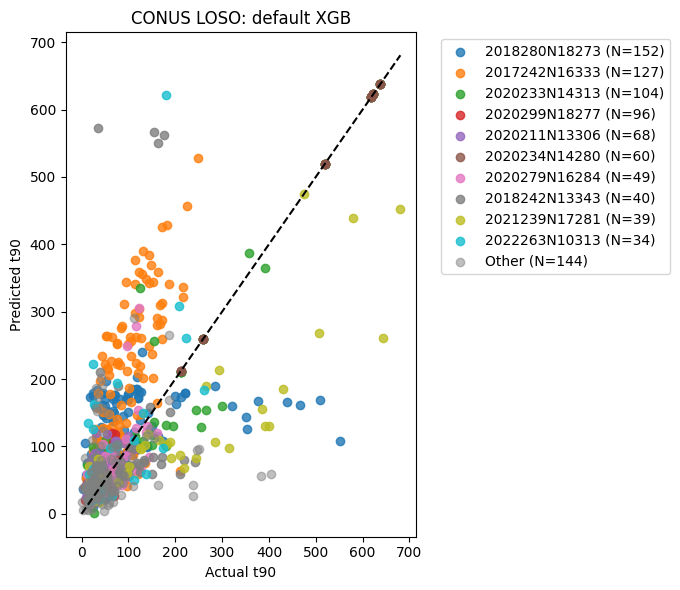

In [60]:
plot_scatter_by_storm(pred_xgb, event_df, "CONUS LOSO: default XGB")

Now for XGB hyperparameter tuning, first testing only learning rate.

Learning-rate sweep results:
 learning_rate  global_mae  global_rmse  mean_fold_mae  std_fold_mae
          0.05   45.597193    77.424922      34.014031     27.369738
          0.02   45.680742    76.450950      35.398468     26.287265
          0.15   45.958775    79.537772      34.153709     28.730856
          0.10   46.052521    78.962379      34.504000     27.404279
          0.07   48.504363    82.978112      34.973836     29.347360
          0.20   48.693559    83.990848      34.704561     30.216979
          0.30   50.333384    85.370354      37.284770     30.353608

Best learning rate: 0.05


C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\382256568.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


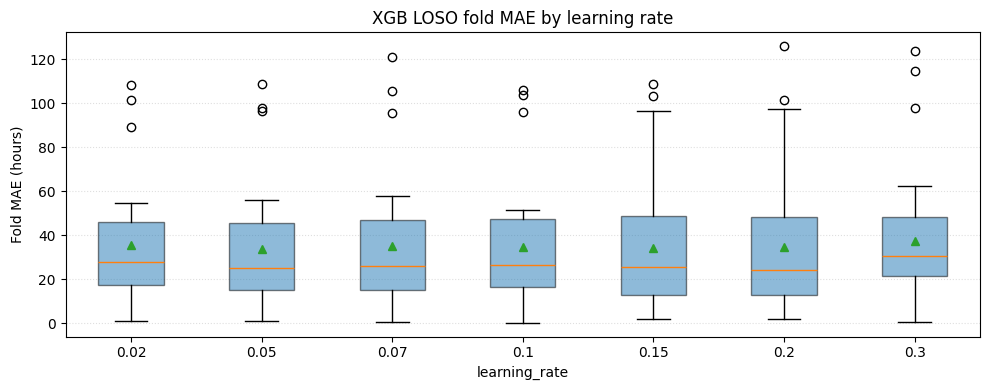

In [61]:
# --- XGB learning-rate sweep on CONUS LOSO (other params held fixed) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

X = event_df[features_v4].copy()
y = event_df["t90"].copy()
groups = event_df["storm"].copy()

# Fixed base settings for the learning-rate sweep.
# Only learning_rate changes in this cell.
base_xgb_params = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "n_estimators": 300,
    "max_depth": 3,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "gamma": 0.0,
    "reg_alpha": 0.0,   # L1
    "reg_lambda": 1.0,  # L2
}

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

logo = LeaveOneGroupOut()

def make_xgb_pipeline(xgb_params):
    return Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBRegressor(**xgb_params)),
    ])

def evaluate_logo_global_model(model, X, y, groups):
    preds = np.full(len(y), np.nan)
    fold_rows = []

    for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_storm = groups.iloc[test_idx].iloc[0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[test_idx] = y_pred
        fold_rows.append({
            "fold": i,
            "storm": test_storm,
            "n": len(test_idx),
            "mae_diagnostic_per_storm": mean_absolute_error(y_test, y_pred),
            "rmse_diagnostic_per_storm": np.sqrt(mean_squared_error(y_test, y_pred)),
        })

    fold_df = pd.DataFrame(fold_rows)
    global_mae = mean_absolute_error(y, preds)
    global_rmse = np.sqrt(mean_squared_error(y, preds))
    return preds, fold_df, global_mae, global_rmse

learning_rates = [0.02, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]

lr_rows = []
lr_fold_mae = {}

for lr in learning_rates:
    params = base_xgb_params.copy()
    params["learning_rate"] = lr

    model = make_xgb_pipeline(params)
    pred_lr, fold_lr, mae_lr, rmse_lr = evaluate_logo_global_model(model, X, y, groups)

    lr_rows.append({
        "learning_rate": lr,
        "global_mae": mae_lr,
        "global_rmse": rmse_lr,
        "mean_fold_mae": fold_lr["mae_diagnostic_per_storm"].mean(),
        "std_fold_mae": fold_lr["mae_diagnostic_per_storm"].std(ddof=0),
    })
    lr_fold_mae[lr] = fold_lr["mae_diagnostic_per_storm"].to_numpy()

lr_results = pd.DataFrame(lr_rows).sort_values("global_mae").reset_index(drop=True)
best_lr = float(lr_results.iloc[0]["learning_rate"])

print("Learning-rate sweep results:")
print(lr_results.to_string(index=False))
print(f"\nBest learning rate: {best_lr}")

# Boxplot of fold MAE by learning rate
fig, ax = plt.subplots(figsize=(10, 4))
data = [lr_fold_mae[lr] for lr in learning_rates]

bp = ax.boxplot(
    data,
    labels=[str(lr) for lr in learning_rates],
    showmeans=True,
    patch_artist=True
)

for patch in bp["boxes"]:
    patch.set_alpha(0.5)

ax.set_xlabel("learning_rate")
ax.set_ylabel("Fold MAE (hours)")
ax.set_title("XGB LOSO fold MAE by learning rate")
ax.grid(True, axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

The below code will use the best learning rate from the previous tuning (best_lr). The first time I ran this, it was 0.05.

In [62]:
best_lr

0.05

Using fixed learning_rate = 0.05


XGB tuning: 100%|██████████| 24/24 [01:18<00:00,  3.27s/it, best_mae=41.195]



Top XGB configurations:
 colsample_bytree  gamma  max_depth  min_child_weight  n_estimators  reg_alpha  reg_lambda  subsample  learning_rate  global_mae  global_rmse  mean_fold_mae  std_fold_mae
              1.0    0.5          4                 1           300        1.0         5.0        1.0           0.05   41.194597    70.960760      31.233526     25.816226
              0.8    0.0          5                 1           200        0.1         5.0        1.0           0.05   41.255819    70.526404      30.611673     25.403234
              0.8    1.0          5                 5           400        1.0         5.0        1.0           0.05   41.772866    71.726660      29.395190     26.188558
              1.0    0.5          4                 3           300        0.0         5.0        0.8           0.05   42.149929    73.390492      30.779069     26.206457
              0.8    1.0          4                 3           300        0.0         5.0        1.0           0.05   4

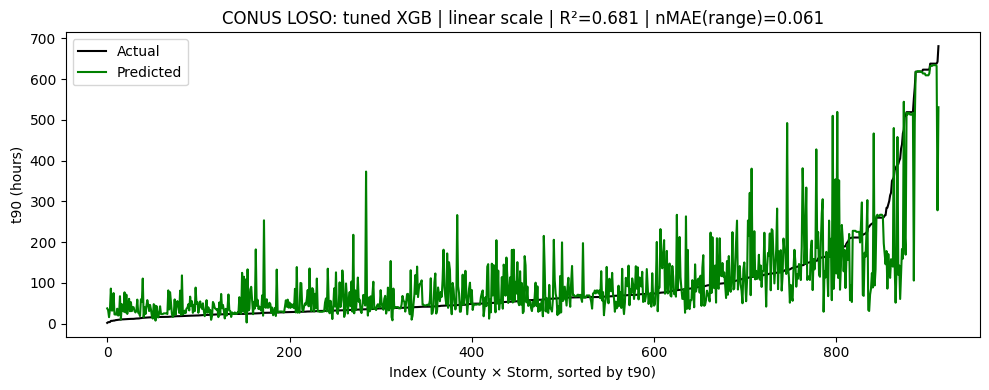

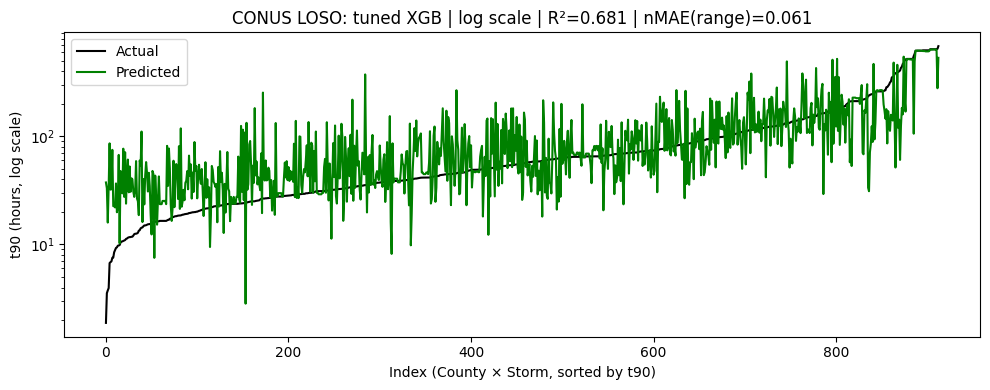

{'mae': 41.194596550516174,
 'rmse': np.float64(70.96076034821706),
 'r2': 0.6814500064815245,
 'nmae_range': np.float64(0.06069860595915647),
 'nmae_mean': np.float64(0.4241510132951433),
 'nrmse_std': np.float64(0.56440233302005),
 'nmse_var': np.float64(0.3185499935184755)}

In [ ]:
# --- XGB tuning with best learning_rate fixed; includes progress indicator ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import ParameterGrid
from tqdm.auto import tqdm

# Reuse the best learning rate from the previous cell
fixed_lr = best_lr
print("Using fixed learning_rate =", fixed_lr)

param_space = {
    "n_estimators": [200, 300, 400],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0.0, 0.5, 1.0],
    "reg_alpha": [0.0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
}

full_grid = list(ParameterGrid(param_space))

# Randomly sample a manageable number of candidates
rng = np.random.default_rng(42)
n_candidates = min(24, len(full_grid))
sample_idx = rng.choice(len(full_grid), size=n_candidates, replace=False)
candidates = [full_grid[i] for i in sample_idx]

search_rows = []

best_so_far = np.inf
best_candidate = None
best_preds = None
best_fold_df = None

pbar = tqdm(candidates, desc="XGB tuning", total=len(candidates))

for cand in pbar:
    params = base_xgb_params.copy()
    params.update(cand)
    params["learning_rate"] = fixed_lr

    model = make_xgb_pipeline(params)
    pred_tmp, fold_tmp, mae_tmp, rmse_tmp = evaluate_logo_global_model(model, X, y, groups)

    search_rows.append({
        **cand,
        "learning_rate": fixed_lr,
        "global_mae": mae_tmp,
        "global_rmse": rmse_tmp,
        "mean_fold_mae": fold_tmp["mae_diagnostic_per_storm"].mean(),
        "std_fold_mae": fold_tmp["mae_diagnostic_per_storm"].std(ddof=0),
    })

    if mae_tmp < best_so_far:
        best_so_far = mae_tmp
        best_candidate = cand.copy()
        best_preds = pred_tmp.copy()
        best_fold_df = fold_tmp.copy()

    pbar.set_postfix(best_mae=f"{best_so_far:.3f}")

xgb_search_df = pd.DataFrame(search_rows).sort_values("global_mae").reset_index(drop=True)

print("\nTop XGB configurations:")
print(xgb_search_df.head(10).to_string(index=False))

print("\nBest XGB params:")
print(best_candidate)
print("Best CV global MAE:", best_so_far)

best_xgb_pipeline = make_xgb_pipeline({
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "learning_rate": fixed_lr,
    "n_estimators": int(best_candidate["n_estimators"]),
    "max_depth": int(best_candidate["max_depth"]),
    "min_child_weight": int(best_candidate["min_child_weight"]),
    "subsample": float(best_candidate["subsample"]),
    "colsample_bytree": float(best_candidate["colsample_bytree"]),
    "gamma": float(best_candidate["gamma"]),
    "reg_alpha": float(best_candidate["reg_alpha"]),
    "reg_lambda": float(best_candidate["reg_lambda"]),
})

pred_xgb_tuned, fold_xgb_tuned, mae_xgb_tuned, rmse_xgb_tuned = evaluate_logo_global_model(
    best_xgb_pipeline, X, y, groups
)

print("\nTuned XGB CONUS global metrics:")
print("Global MAE:", mae_xgb_tuned)
print("Global RMSE:", rmse_xgb_tuned)

print("\nPer-storm diagnostics:")
print(fold_xgb_tuned.sort_values("mae_diagnostic_per_storm", ascending=False).to_string(index=False))

report_ranked_predictions(pred_xgb_tuned, event_df, "CONUS LOSO: tuned XGB")

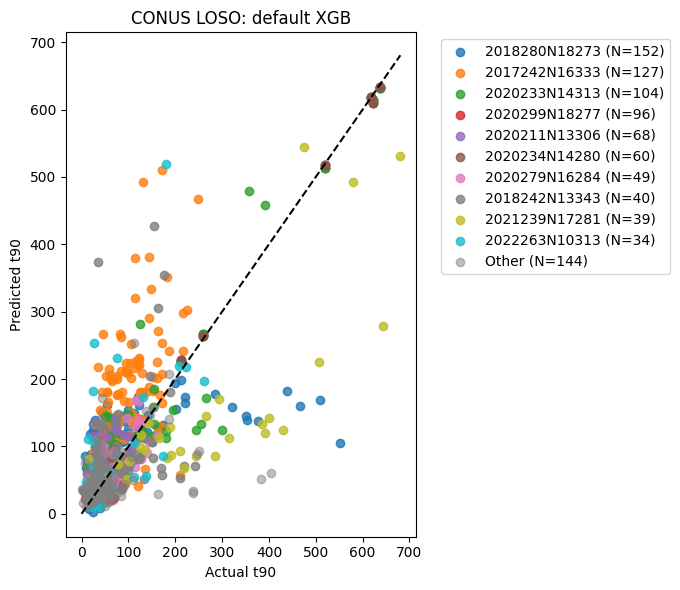

In [65]:
plot_scatter_by_storm(pred_xgb_tuned, event_df, "CONUS LOSO: default XGB")

C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2654084495.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2654084495.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2654084495.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2654084495.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

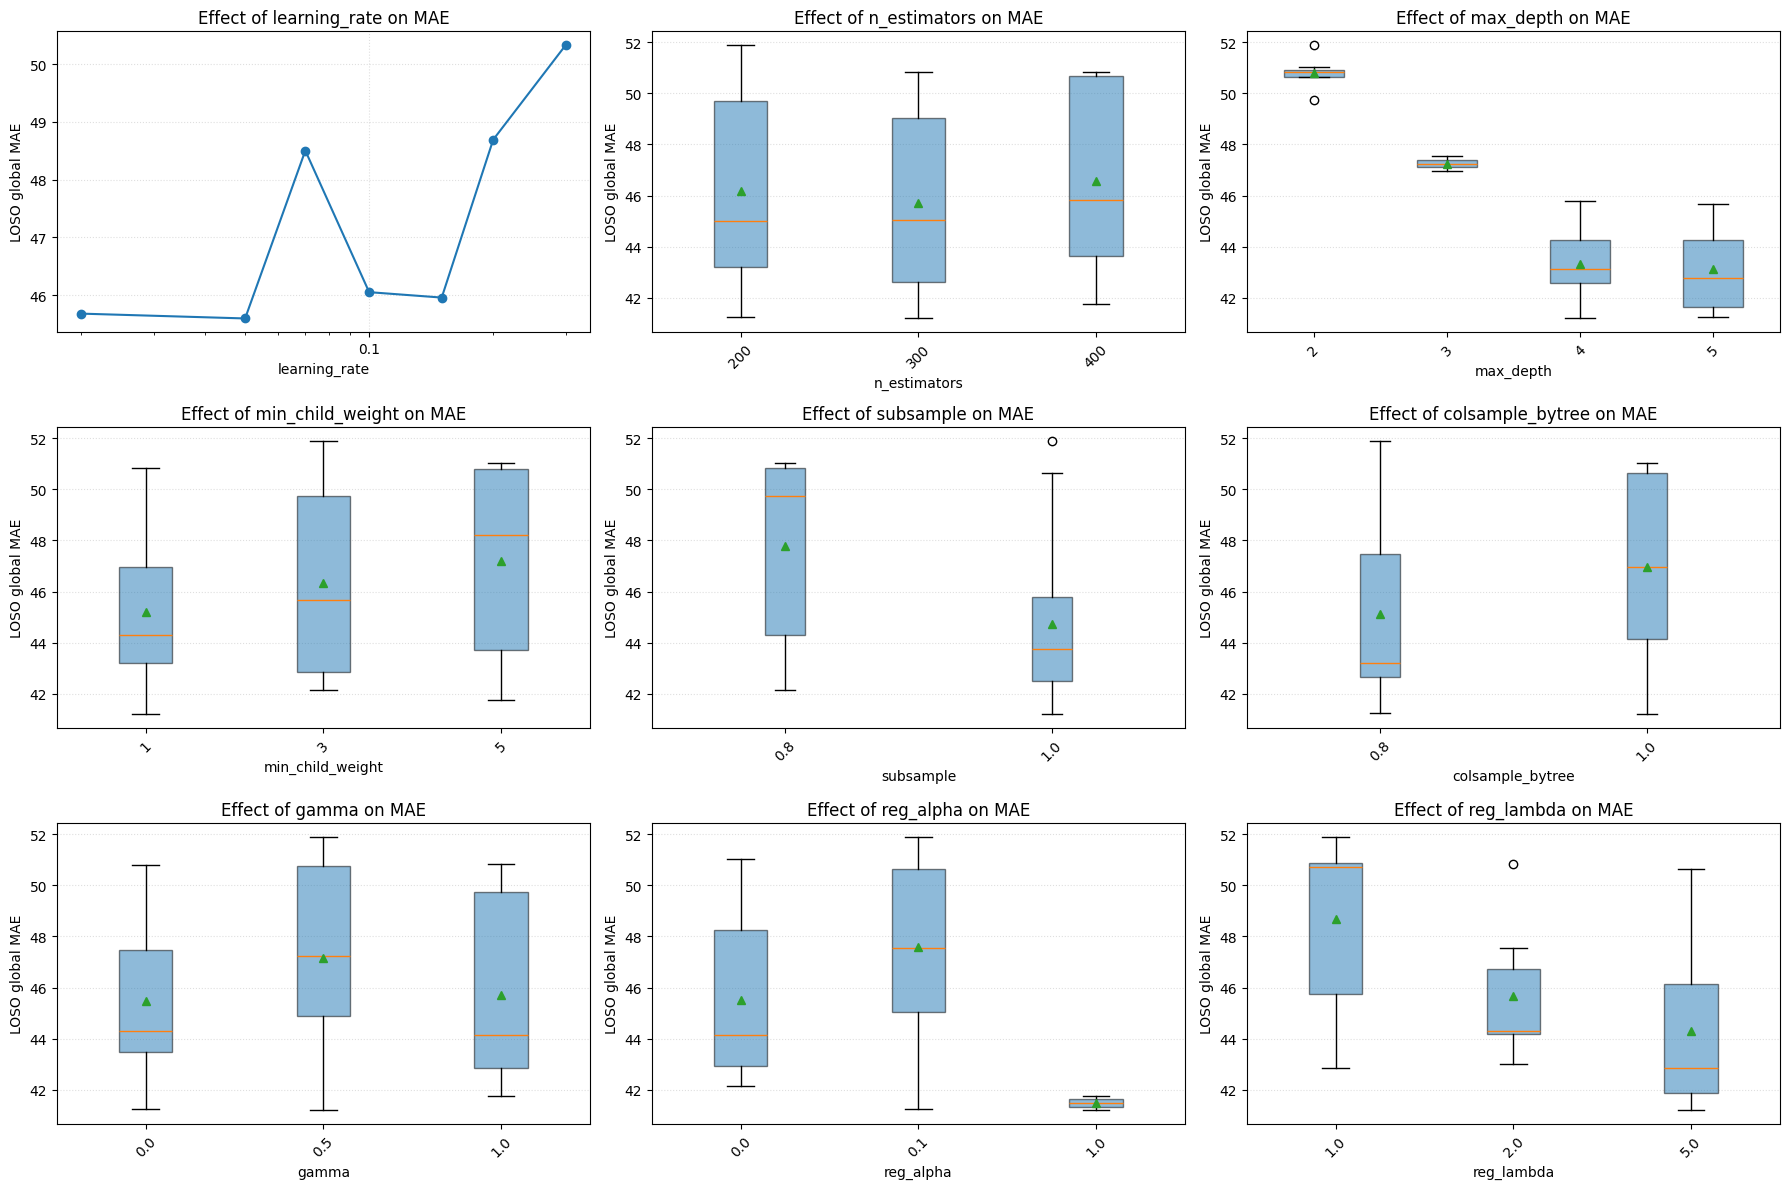

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_xgb_hparam_effects(xgb_search_df, lr_results=None, metric_col="global_mae"):
    """
    Plot hyperparameter effects on LOSO global MAE.

    - learning_rate: uses lr_results if provided; shown as a line with markers
    - other params: shown as boxplots from xgb_search_df
    """
    params = [
        "learning_rate",
        "n_estimators",
        "max_depth",
        "min_child_weight",
        "subsample",
        "colsample_bytree",
        "gamma",
        "reg_alpha",
        "reg_lambda",
    ]

    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.ravel()

    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    def _boxplot_param(ax, df, param, color_idx=0):
        dfp = df[[param, metric_col]].dropna().copy()

        # Sort values numerically when possible
        try:
            values = sorted(dfp[param].unique())
        except Exception:
            values = list(dfp[param].unique())

        grouped = [dfp.loc[dfp[param] == v, metric_col].to_numpy() for v in values]

        if len(values) == 1:
            ax.scatter([0], grouped[0], color=default_colors[color_idx % len(default_colors)], alpha=0.8)
            ax.set_xticks([0])
            ax.set_xticklabels([str(values[0])])
        else:
            bp = ax.boxplot(
                grouped,
                labels=[str(v) for v in values],
                showmeans=True,
                patch_artist=True,
            )
            for patch in bp["boxes"]:
                patch.set_alpha(0.5)

        ax.set_xlabel(param)
        ax.set_ylabel("LOSO global MAE")
        ax.grid(True, axis="y", linestyle=":", alpha=0.4)
        ax.tick_params(axis="x", rotation=45)

    # Panel 1: learning rate from the separate sweep
    ax = axes[0]
    if lr_results is not None and len(lr_results) > 0:
        df_lr = lr_results.copy().sort_values("learning_rate")
        ax.plot(
            df_lr["learning_rate"],
            df_lr[metric_col],
            marker="o",
            color=default_colors[0],
        )
        ax.set_xscale("log")
        ax.set_xlabel("learning_rate")
        ax.set_ylabel("LOSO global MAE")
        ax.set_title("Effect of learning_rate on MAE")
        ax.grid(True, axis="both", linestyle=":", alpha=0.4)

        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))
    else:
        _boxplot_param(ax, xgb_search_df, "learning_rate")
        ax.set_title("Effect of learning_rate on MAE")

    # Remaining params from the fixed-learning-rate tuning search
    for i, param in enumerate(params[1:], start=1):
        ax = axes[i]
        if param not in xgb_search_df.columns:
            ax.axis("off")
            continue

        _boxplot_param(ax, xgb_search_df, param)
        ax.set_title(f"Effect of {param} on MAE")

    plt.tight_layout()
    plt.show()

# Call it like this:
plot_xgb_hparam_effects(xgb_search_df, lr_results=lr_results)

Round Two of Hyperparameter tuning, based on trends seen in the above plots.

Using fixed learning_rate = 0.05


Second-round XGB tuning: 100%|██████████| 48/48 [03:15<00:00,  4.07s/it]



Top XGB configurations from second round:
 colsample_bytree  gamma  max_depth  min_child_weight  n_estimators  reg_alpha  reg_lambda  subsample  learning_rate  global_mae  global_rmse  mean_fold_mae  std_fold_mae
              0.9    0.0          6                 2           300        1.0        10.0        1.0           0.05   38.452710    66.727777      28.980506     24.398365
              0.6    1.0          6                 1           200        2.0        20.0        1.0           0.05   38.907389    65.509942      30.204960     22.697789
              0.6    0.0          6                 2           200        0.5        20.0        1.0           0.05   39.004238    66.156059      29.927463     22.814091
              0.6    0.0          6                 1           400        1.0        10.0        1.0           0.05   39.012192    66.669812      29.445274     23.693659
              0.9    0.5          6                 1           200        2.0        10.0        0.8 

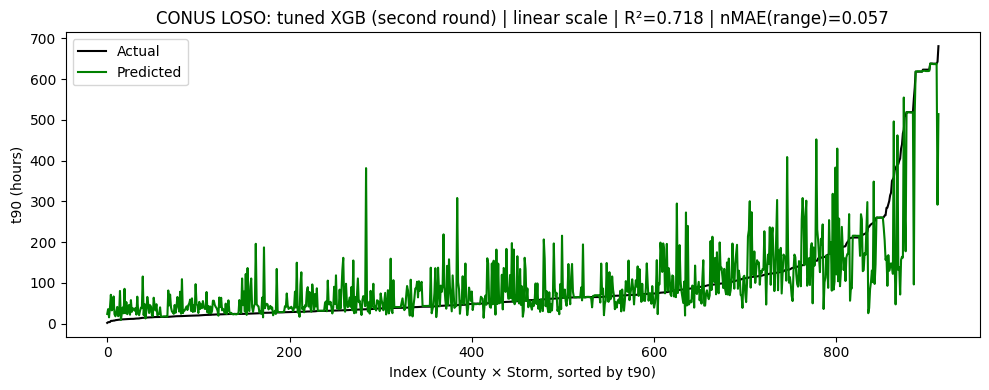

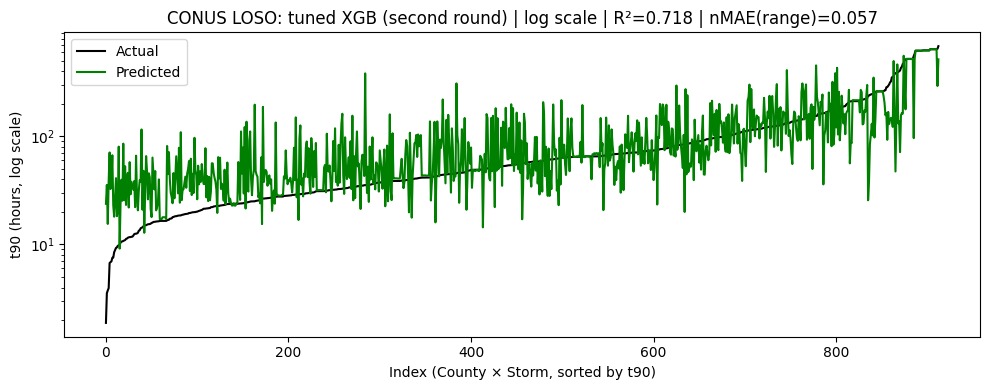

C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2654084495.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2654084495.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2654084495.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2654084495.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

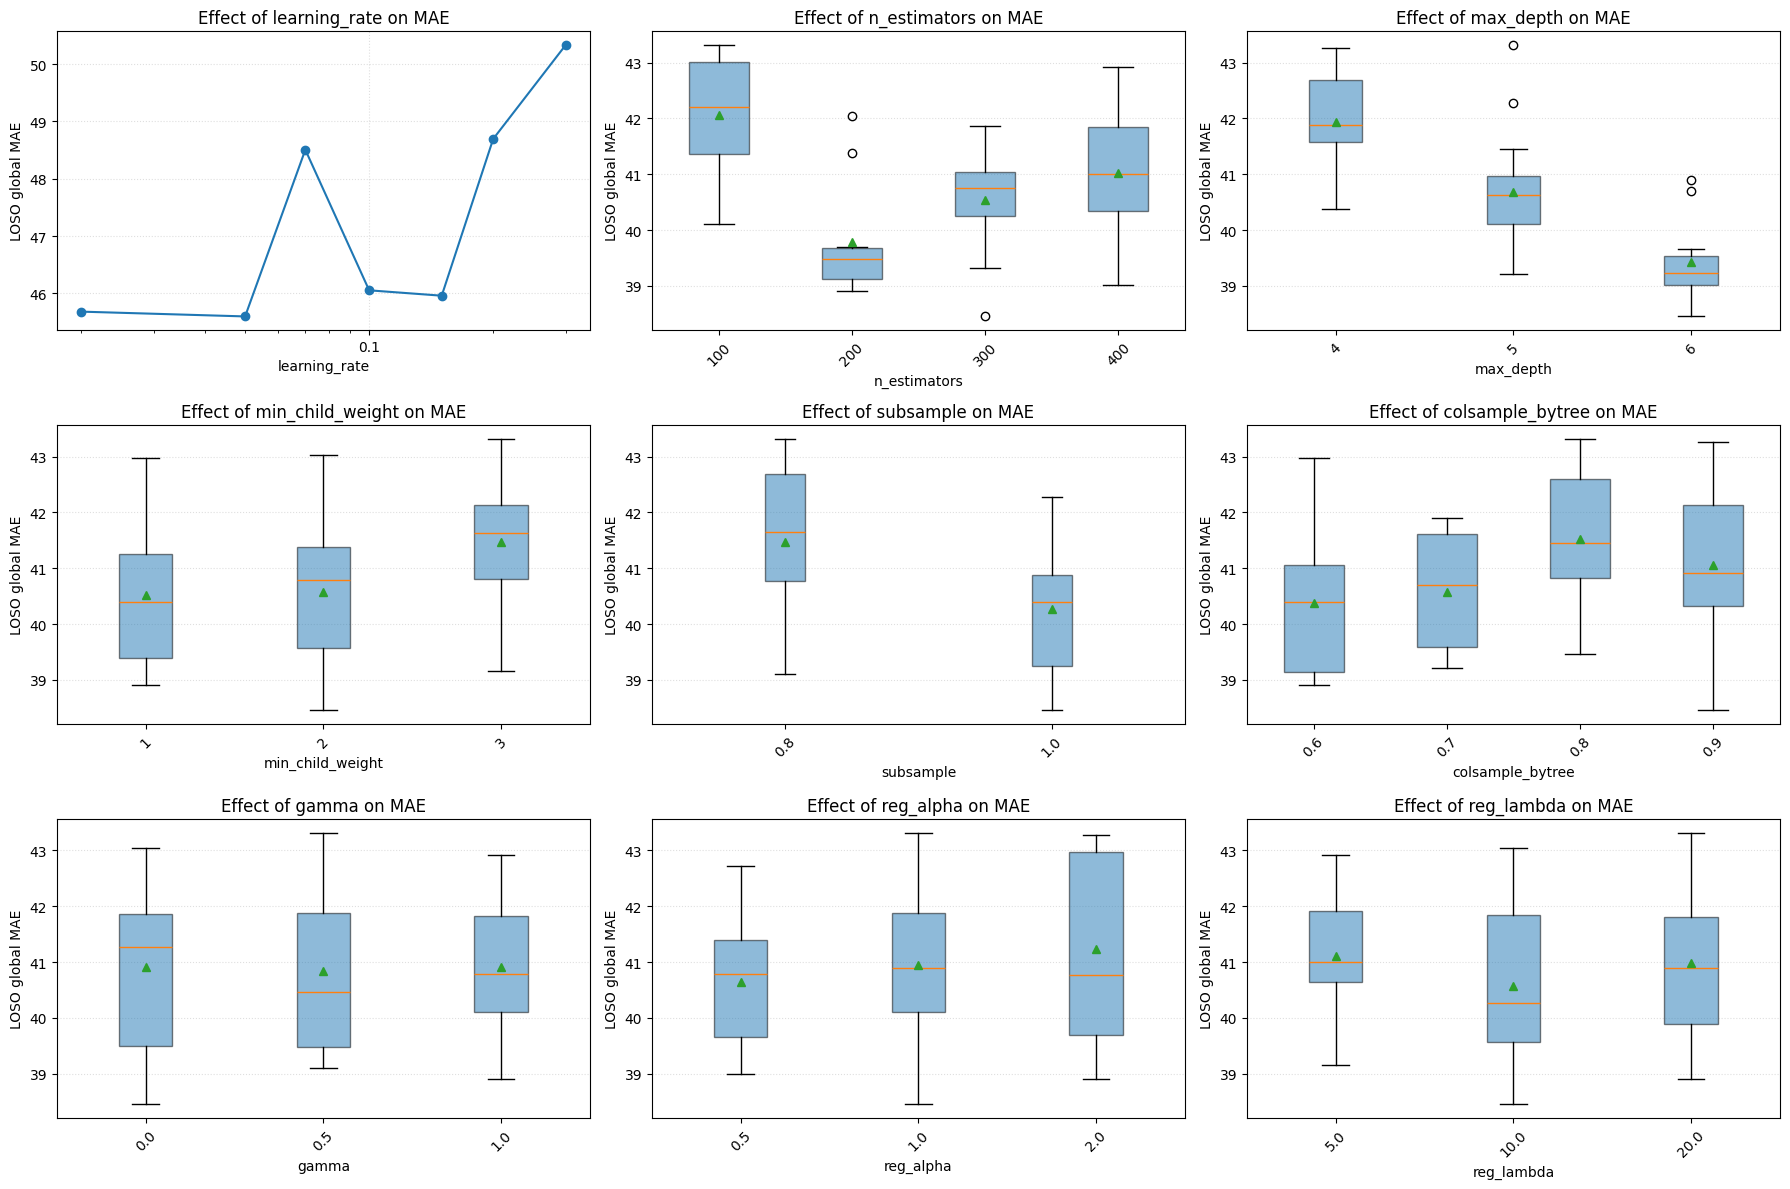

In [67]:
# --- Second-round XGB tuning on CONUS with learning_rate fixed ---

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import ParameterGrid

if "best_lr" in globals():
    fixed_lr = float(best_lr)
else:
    fixed_lr = 0.05

print("Using fixed learning_rate =", fixed_lr)

# Tighter second-round search space around the promising region
param_space_2 = {
    "n_estimators": [100, 200, 300, 400], # (no huge effect last time)
    "max_depth": [4, 5, 6], # (4-5 looked good in the first round, but let's see if 6 helps)
    "min_child_weight": [1, 2, 3], # same (not huge effect last time)
    "subsample": [0.8, 1.0], # same (not huge effect last time)
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9], # perhaps slightly lower is better?
    "gamma": [0.0, 0.5, 1.0], # no obv trend last time
    "reg_alpha": [0.5, 1.0, 2.0], # 1.0 was really good last time, so let's see if we can do better by going higher
    "reg_lambda": [5.0, 10.0, 20.0], # 5.0 was best last time, so let's see if we can do better by going higher
}

full_grid_2 = list(ParameterGrid(param_space_2))

# Sample a manageable number of candidates so LOSO stays tractable
rng = np.random.default_rng(42)
n_candidates_2 = min(48, len(full_grid_2))
sample_idx_2 = rng.choice(len(full_grid_2), size=n_candidates_2, replace=False)
candidates_2 = [full_grid_2[i] for i in sample_idx_2]

xgb_search_rows_2 = []
best_mae_2 = np.inf
best_candidate_2 = None
best_preds_2 = None
best_fold_df_2 = None

for cand in tqdm(candidates_2, desc="Second-round XGB tuning"):
    params = {
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
        "learning_rate": fixed_lr,
        **cand,
    }

    model = make_xgb_pipeline(params)
    pred_tmp, fold_tmp, mae_tmp, rmse_tmp = evaluate_logo_global_model(model, X, y, groups)

    xgb_search_rows_2.append({
        **cand,
        "learning_rate": fixed_lr,
        "global_mae": mae_tmp,
        "global_rmse": rmse_tmp,
        "mean_fold_mae": fold_tmp["mae_diagnostic_per_storm"].mean(),
        "std_fold_mae": fold_tmp["mae_diagnostic_per_storm"].std(ddof=0),
    })

    if mae_tmp < best_mae_2:
        best_mae_2 = mae_tmp
        best_candidate_2 = cand.copy()
        best_preds_2 = pred_tmp.copy()
        best_fold_df_2 = fold_tmp.copy()

xgb_search_df_2 = pd.DataFrame(xgb_search_rows_2).sort_values("global_mae").reset_index(drop=True)

print("\nTop XGB configurations from second round:")
print(xgb_search_df_2.head(10).to_string(index=False))

print("\nBest XGB params from second round:")
print(best_candidate_2)
print("Best CV global MAE:", best_mae_2)

best_xgb_pipeline_2 = make_xgb_pipeline({
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "learning_rate": fixed_lr,
    "n_estimators": int(best_candidate_2["n_estimators"]),
    "max_depth": int(best_candidate_2["max_depth"]),
    "min_child_weight": int(best_candidate_2["min_child_weight"]),
    "subsample": float(best_candidate_2["subsample"]),
    "colsample_bytree": float(best_candidate_2["colsample_bytree"]),
    "gamma": float(best_candidate_2["gamma"]),
    "reg_alpha": float(best_candidate_2["reg_alpha"]),
    "reg_lambda": float(best_candidate_2["reg_lambda"]),
})

pred_xgb_tuned_2, fold_xgb_tuned_2, mae_xgb_tuned_2, rmse_xgb_tuned_2 = evaluate_logo_global_model(
    best_xgb_pipeline_2, X, y, groups
)

print("\nTuned XGB CONUS global metrics:")
print("Global MAE:", mae_xgb_tuned_2)
print("Global RMSE:", rmse_xgb_tuned_2)

print("\nPer-storm diagnostics:")
print(fold_xgb_tuned_2.sort_values("mae_diagnostic_per_storm", ascending=False).to_string(index=False))

report_ranked_predictions(pred_xgb_tuned_2, event_df, "CONUS LOSO: tuned XGB (second round)")

plot_xgb_hparam_effects(
    xgb_search_df_2,
    lr_results=lr_results if "lr_results" in globals() else None
)

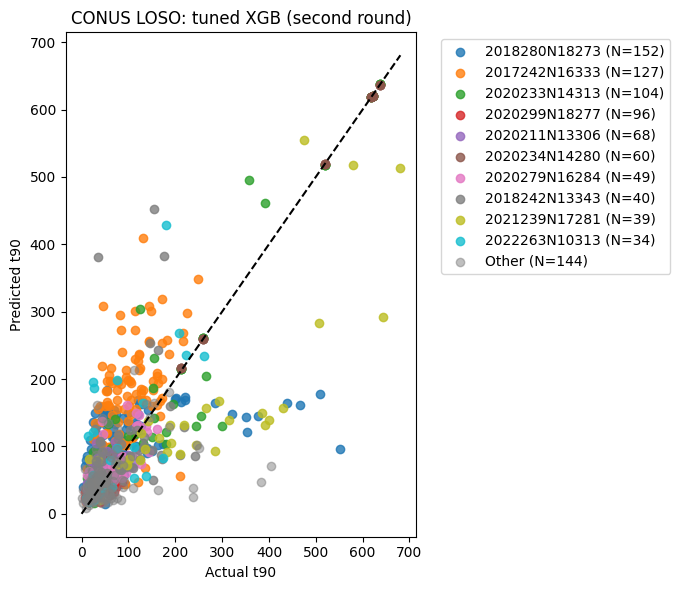

In [68]:
#  Some plots:

plot_scatter_by_storm(pred_xgb_tuned_2, event_df, "CONUS LOSO: tuned XGB (second round)")


**Round 3:**

Third-round XGB tuning: 100%|██████████| 48/48 [04:39<00:00,  5.83s/it]



Top XGB configurations from third round:
 colsample_bytree  gamma  learning_rate  max_depth  min_child_weight  n_estimators  reg_alpha  reg_lambda  subsample  global_mae  global_rmse  mean_fold_mae  std_fold_mae
              0.7    0.5           0.30          6                 1           100        0.0         8.0        1.0   36.098640    63.701177      28.284882     22.965023
              0.6    0.0           0.50         12                 2           150        0.0        10.0        1.0   36.764781    64.000734      29.264864     23.154430
              0.6    0.0           0.30         14                 1           200        1.0        10.0        1.0   37.318330    65.997843      30.667486     23.635909
              0.7    0.5           0.07          8                 1           300        0.5        10.0        1.0   37.670329    65.348220      29.333000     23.349179
              0.6    0.5           0.20         14                 1           200        1.5        10

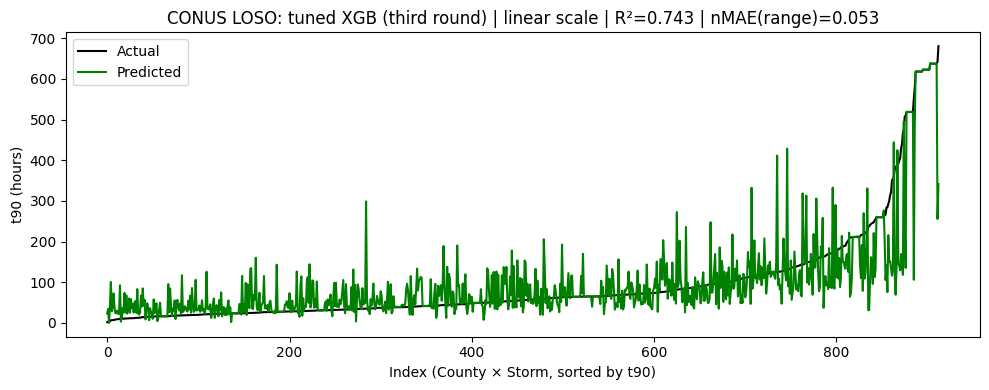

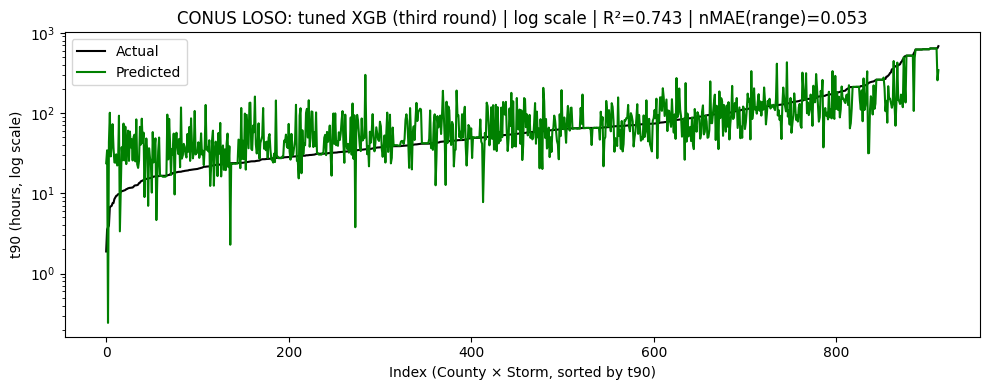

{'mae': 36.09863965624136,
 'rmse': np.float64(63.701177078627616),
 'r2': 0.7432940147450833,
 'nmae_range': np.float64(0.05318991536836204),
 'nmae_mean': np.float64(0.37168162504019386),
 'nrmse_std': np.float64(0.5066616082306975),
 'nmse_var': np.float64(0.2567059852549168)}

In [74]:
# --- Third-round XGB tuning on CONUS with learning_rate included ---

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import ParameterGrid

# Same learning-rate values as before
learning_rates_3 = [0.07, 0.10, 0.15, 0.20, 0.30, 0.4, 0.5, 0.6]

# Tighter third-round search space around the promising region
param_space_3 = {
    "learning_rate": learning_rates_3,
    "n_estimators": [100, 150, 200, 300], # why isn't 100 showing in the boxplot?
    "max_depth": [6, 7, 8, 10, 12, 14],
    "min_child_weight": [1, 2],
    "subsample": [1.0],
    "colsample_bytree": [0.6, 0.7, 0.9],
    "gamma": [0.0, 0.5, 1.0],
    "reg_alpha": [0.0, 0.5, 1.0, 1.5],
    "reg_lambda": [5.0, 8.0, 10.0],
}

full_grid_3 = list(ParameterGrid(param_space_3))

# Sample a manageable number of candidates so LOSO stays tractable
rng = np.random.default_rng(42)
n_candidates_3 = min(48, len(full_grid_3))
sample_idx_3 = rng.choice(len(full_grid_3), size=n_candidates_3, replace=False)
candidates_3 = [full_grid_3[i] for i in sample_idx_3]

xgb_search_rows_3 = []
best_mae_3 = np.inf
best_candidate_3 = None
best_preds_3 = None
best_fold_df_3 = None

for cand in tqdm(candidates_3, desc="Third-round XGB tuning"):
    params = {
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
        **cand,
    }

    model = make_xgb_pipeline(params)
    pred_tmp, fold_tmp, mae_tmp, rmse_tmp = evaluate_logo_global_model(model, X, y, groups)

    xgb_search_rows_3.append({
        **cand,
        "global_mae": mae_tmp,
        "global_rmse": rmse_tmp,
        "mean_fold_mae": fold_tmp["mae_diagnostic_per_storm"].mean(),
        "std_fold_mae": fold_tmp["mae_diagnostic_per_storm"].std(ddof=0),
    })

    if mae_tmp < best_mae_3:
        best_mae_3 = mae_tmp
        best_candidate_3 = cand.copy()
        best_preds_3 = pred_tmp.copy()
        best_fold_df_3 = fold_tmp.copy()

xgb_search_df_3 = pd.DataFrame(xgb_search_rows_3).sort_values("global_mae").reset_index(drop=True)

print("\nTop XGB configurations from third round:")
print(xgb_search_df_3.head(10).to_string(index=False))

print("\nBest XGB params from third round:")
print(best_candidate_3)
print("Best CV global MAE:", best_mae_3)

best_xgb_pipeline_3 = make_xgb_pipeline({
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "learning_rate": float(best_candidate_3["learning_rate"]),
    "n_estimators": int(best_candidate_3["n_estimators"]),
    "max_depth": int(best_candidate_3["max_depth"]),
    "min_child_weight": int(best_candidate_3["min_child_weight"]),
    "subsample": float(best_candidate_3["subsample"]),
    "colsample_bytree": float(best_candidate_3["colsample_bytree"]),
    "gamma": float(best_candidate_3["gamma"]),
    "reg_alpha": float(best_candidate_3["reg_alpha"]),
    "reg_lambda": float(best_candidate_3["reg_lambda"]),
})

pred_xgb_tuned_3, fold_xgb_tuned_3, mae_xgb_tuned_3, rmse_xgb_tuned_3 = evaluate_logo_global_model(
    best_xgb_pipeline_3, X, y, groups
)

print("\nTuned XGB CONUS global metrics:")
print("Global MAE:", mae_xgb_tuned_3)
print("Global RMSE:", rmse_xgb_tuned_3)

print("\nPer-storm diagnostics:")
print(fold_xgb_tuned_3.sort_values("mae_diagnostic_per_storm", ascending=False).to_string(index=False))

report_ranked_predictions(pred_xgb_tuned_3, event_df, "CONUS LOSO: tuned XGB (third round)")

C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2053413466.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2053413466.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2053413466.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2053413466.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

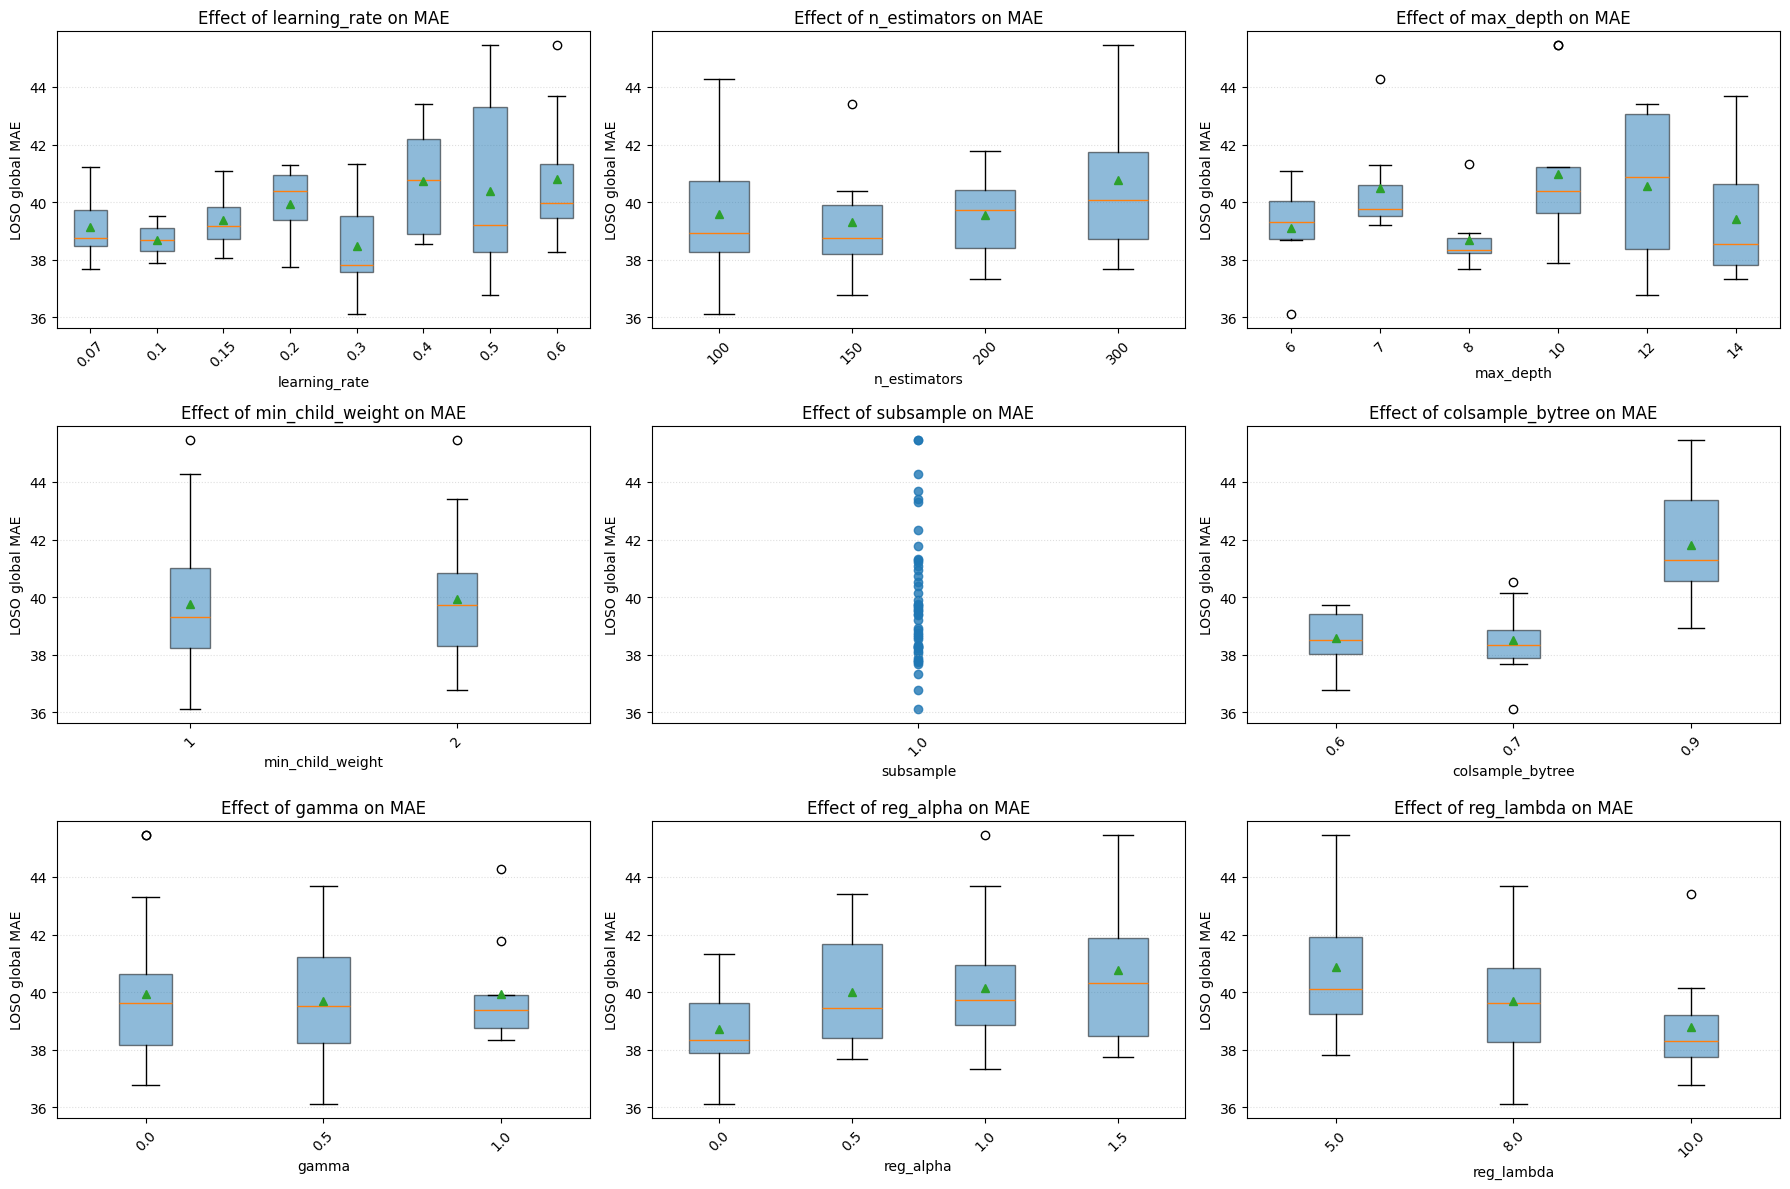

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_xgb_hparam_effects(xgb_search_df, metric_col="global_mae"):
    """
    Plot hyperparameter effects on LOSO global MAE using boxplots for all params,
    including learning_rate.
    """
    params = [
        "learning_rate",
        "n_estimators",
        "max_depth",
        "min_child_weight",
        "subsample",
        "colsample_bytree",
        "gamma",
        "reg_alpha",
        "reg_lambda",
    ]

    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.ravel()

    def _boxplot_param(ax, df, param):
        dfp = df[[param, metric_col]].dropna().copy()

        values = sorted(dfp[param].unique())
        grouped = [dfp.loc[dfp[param] == v, metric_col].to_numpy() for v in values]

        if len(values) == 1:
            y = grouped[0]
            x = np.zeros(len(y))
            ax.scatter(x, y, alpha=0.8)
            ax.set_xticks([0])
            ax.set_xticklabels([str(values[0])])
        else:
            bp = ax.boxplot(
                grouped,
                labels=[str(v) for v in values],
                showmeans=True,
                patch_artist=True,
            )
            for patch in bp["boxes"]:
                patch.set_alpha(0.5)

        ax.set_xlabel(param)
        ax.set_ylabel("LOSO global MAE")
        ax.grid(True, axis="y", linestyle=":", alpha=0.4)
        ax.tick_params(axis="x", rotation=45)

    for ax, param in zip(axes, params):
        if param not in xgb_search_df.columns:
            ax.axis("off")
            continue
        _boxplot_param(ax, xgb_search_df, param)
        ax.set_title(f"Effect of {param} on MAE")

    plt.tight_layout()
    plt.show()

plot_xgb_hparam_effects(xgb_search_df_3)

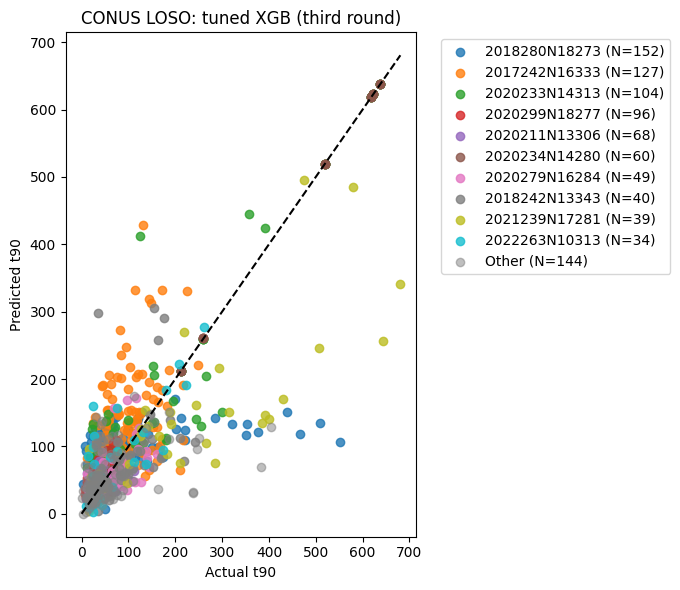

In [76]:
plot_scatter_by_storm(pred_xgb_tuned_3, event_df, "CONUS LOSO: tuned XGB (third round)")


**NOW TRYING REPEATED 5-FOLD CV FOR ALL MODELS** (for RF and XGB, use the best hyperparameters from the above tuning)

In [98]:
# --- Repeated 5-fold CV comparison on CONUS using LOSO-tuned hyperparameters ---
# FL-style repeated CV: compute metrics on each fold, then summarize mean + sd across folds.

import numpy as np
import pandas as pd

from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

X = event_df[features_v4].copy()
y = event_df["t90"].copy()

rkf = RepeatedKFold(n_splits=5, n_repeats=20, random_state=42)

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

rf_best_params = {
    "n_estimators": 400,
    "max_depth": 20,
    "min_samples_leaf": 1,
    "max_features": 0.1,
    "random_state": 42,
    "n_jobs": -1,
}

if "best_candidate_3" in globals():
    xgb_best_params = {
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
        "learning_rate": float(best_candidate_3["learning_rate"]),
        "n_estimators": int(best_candidate_3["n_estimators"]),
        "max_depth": int(best_candidate_3["max_depth"]),
        "min_child_weight": int(best_candidate_3["min_child_weight"]),
        "subsample": float(best_candidate_3["subsample"]),
        "colsample_bytree": float(best_candidate_3["colsample_bytree"]),
        "gamma": float(best_candidate_3["gamma"]),
        "reg_alpha": float(best_candidate_3["reg_alpha"]),
        "reg_lambda": float(best_candidate_3["reg_lambda"]),
    }
else:
    raise RuntimeError("best_candidate_3 is missing. Run the XGB tuning cell first.")

def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def evaluate_repeated_kfold(model_factory, X, y, splitter):
    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X), start=1):
        model = model_factory()

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        metrics = compute_metrics(y_test, preds)
        metrics["fold"] = fold
        fold_rows.append(metrics)

    return pd.DataFrame(fold_rows)

def evaluate_mean_repeated_kfold(y, splitter):
    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(np.zeros(len(y))), start=1):
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        preds = np.full(len(y_test), float(y_train.mean()))
        metrics = compute_metrics(y_test, preds)
        metrics["fold"] = fold
        fold_rows.append(metrics)

    return pd.DataFrame(fold_rows)

def make_mlr_model():
    return Pipeline([
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ])

def make_rf_model():
    return Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(**rf_best_params))
    ])

def make_xgb_model():
    return Pipeline([
        ("preprocess", preprocess),
        ("model", XGBRegressor(**xgb_best_params))
    ])

mean_random_cv_df = evaluate_mean_repeated_kfold(y, rkf)
mlr_random_cv_df = evaluate_repeated_kfold(make_mlr_model, X, y, rkf)
rf_random_cv_df = evaluate_repeated_kfold(make_rf_model, X, y, rkf)
xgb_random_cv_df = evaluate_repeated_kfold(make_xgb_model, X, y, rkf)

def summarize_cv_results(name, df):
    return {
        "Model": name,
        "Evaluation": "Repeated 5-fold CV",
        "MAE_mean": df["MAE"].mean(),
        "MAE_sd": df["MAE"].std(),
        "RMSE_mean": df["RMSE"].mean(),
        "RMSE_sd": df["RMSE"].std(),
        "R2_mean": df["R2"].mean(),
        "R2_sd": df["R2"].std(),
    }

results_df = pd.DataFrame([
    summarize_cv_results("Mean", mean_random_cv_df),
    summarize_cv_results("MLR", mlr_random_cv_df),
    summarize_cv_results("RF", rf_random_cv_df),
    summarize_cv_results("XGB", xgb_random_cv_df),
])

print(results_df.to_string(index=False))

Model         Evaluation  MAE_mean   MAE_sd  RMSE_mean   RMSE_sd   R2_mean    R2_sd
 Mean Repeated 5-fold CV 77.896188 5.720079 125.193351 12.993965 -0.005919 0.007320
  MLR Repeated 5-fold CV 59.889321 4.328874  95.751896 11.544343  0.404118 0.114842
   RF Repeated 5-fold CV 28.340664 2.632863  51.461233  8.114901  0.824401 0.053704
  XGB Repeated 5-fold CV 28.084454 3.074873  51.745849  8.042983  0.821300 0.059797


These boxplots summarize the 100 fold-level scores from repeated 5-fold CV.
Lower MAE/RMSE is better; higher R² is better.
The spread reflects sensitivity to how storms/events are split across folds,
not an uncertainty interval for individual predictions.


C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2781760051.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2781760051.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\teaching\AppData\Local\Temp\ipykernel_20772\2781760051.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


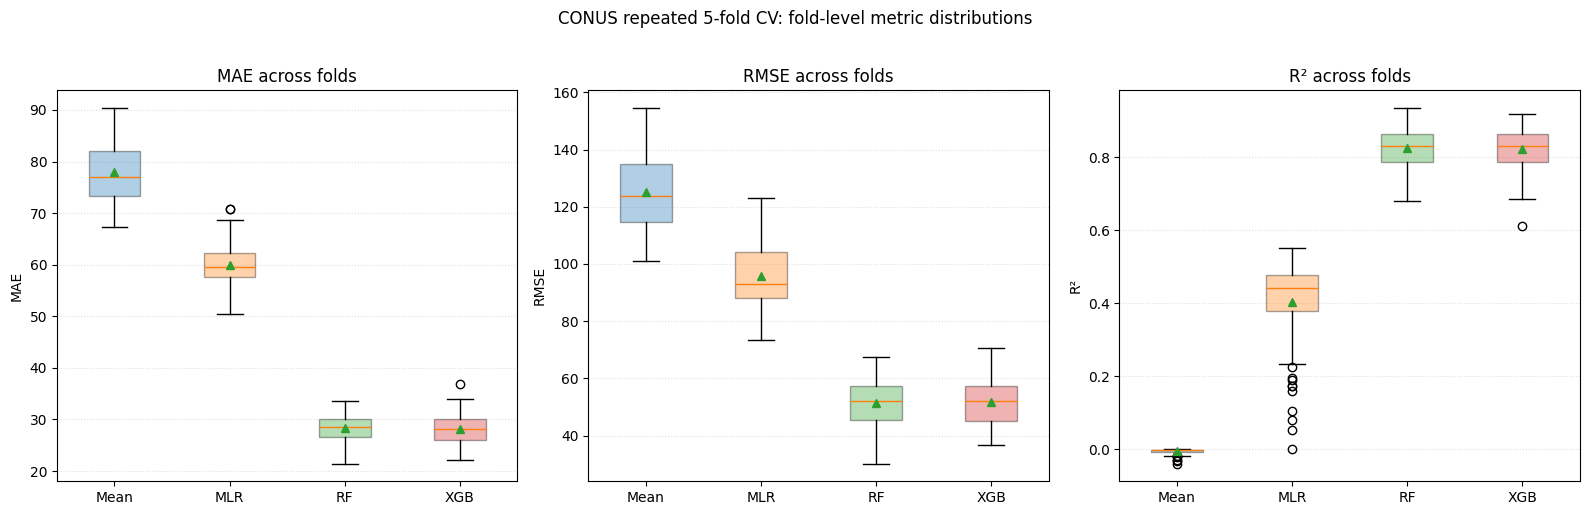


Interpretation note:
Each box shows the distribution of fold scores across repeated 5-fold splits.
This is the FL-style repeated-CV view: it tells you how stable each model is
under different random fold assignments. It is not a pooled actual-vs-predicted plot.


In [99]:
# --- Repeated 5-fold CV plots for the tuned XGB model ---
# These plots show fold-level distributions across the 100 repeated 5-fold splits.
# They match the Florida-style repeated-CV convention used in the table above.

import numpy as np
import matplotlib.pyplot as plt

print(
    "These boxplots summarize the 100 fold-level scores from repeated 5-fold CV.\n"
    "Lower MAE/RMSE is better; higher R² is better.\n"
    "The spread reflects sensitivity to how storms/events are split across folds,\n"
    "not an uncertainty interval for individual predictions."
)

def plot_repeated_cv_metric_boxes(model_dfs, title_prefix="Repeated 5-fold CV"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    metric_info = [
        ("MAE", "MAE"),
        ("RMSE", "RMSE"),
        ("R2", "R²"),
    ]

    models_in_order = ["Mean", "MLR", "RF", "XGB"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, (col, label) in zip(axes, metric_info):
        data = [model_dfs[m][col].to_numpy() for m in models_in_order]

        bp = ax.boxplot(
            data,
            labels=models_in_order,
            showmeans=True,
            patch_artist=True,
        )

        for i, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(colors[i % len(colors)])
            patch.set_alpha(0.35)

        ax.set_title(f"{label} across folds")
        ax.set_ylabel(label)
        ax.grid(True, axis="y", linestyle=":", alpha=0.4)

    fig.suptitle(f"{title_prefix}: fold-level metric distributions", y=1.02)
    plt.tight_layout()
    plt.show()

    print(
        "\nInterpretation note:\n"
        "Each box shows the distribution of fold scores across repeated 5-fold splits.\n"
        "This is the FL-style repeated-CV view: it tells you how stable each model is\n"
        "under different random fold assignments. It is not a pooled actual-vs-predicted plot."
    )

model_fold_dfs = {
    "Mean": mean_random_cv_df,
    "MLR": mlr_random_cv_df,
    "RF": rf_random_cv_df,
    "XGB": xgb_random_cv_df,
}

plot_repeated_cv_metric_boxes(model_fold_dfs, title_prefix="CONUS repeated 5-fold CV")

Some stats about the CONUS data:

In [100]:
# --- Dataset summary: key counts and dimensions ---

import pandas as pd

df = event_df.copy()

# Standardize keys for counting
df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df["storm"] = df["storm"].astype(str)

n_rows = len(df)
n_storms = df["storm"].nunique(dropna=True)
n_counties = df["CountyFIPS"].nunique(dropna=True)

# County-storm event count
event_pairs = df[["storm", "CountyFIPS"]].drop_duplicates()
n_event_pairs = len(event_pairs)

# Extra useful summaries
storm_counts = df["storm"].value_counts()
county_counts = df["CountyFIPS"].value_counts()

print("Dataset summary")
print("----------------")
print(f"Rows (county-event observations): {n_rows}")
print(f"Unique storms: {n_storms}")
print(f"Unique counties: {n_counties}")
print(f"Unique storm-county event pairs: {n_event_pairs}")
print()
print("Storms per county-event table:")
print(df.groupby("storm").size().describe().to_string())
print()
print("Counties per storm:")
print(storm_counts.describe().to_string())
print()
print("Events per county:")
print(county_counts.describe().to_string())

print()
print("Top 10 storms by number of events:")
print(storm_counts.head(10).to_string())

print()
print("Top 10 counties by number of events:")
print(county_counts.head(10).to_string())

Dataset summary
----------------
Rows (county-event observations): 913
Unique storms: 28
Unique counties: 560
Unique storm-county event pairs: 817

Storms per county-event table:
count     28.000000
mean      32.607143
std       41.416886
min        1.000000
25%        4.000000
50%       12.500000
75%       42.250000
max      152.000000

Counties per storm:
count     28.000000
mean      32.607143
std       41.416886
min        1.000000
25%        4.000000
50%       12.500000
75%       42.250000
max      152.000000

Events per county:
count    560.000000
mean       1.630357
std        1.475188
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000

Top 10 storms by number of events:
storm
2018280N18273    152
2017242N16333    127
2020233N14313    104
2020299N18277     96
2020211N13306     68
2020234N14280     60
2020279N16284     49
2018242N13343     40
2021239N17281     39
2022263N10313     34

Top 10 counties by number of events:
CountyFIPS

In [103]:
# --- Dataset summary from saved CONUS tables (robust version) ---

import pandas as pd

full_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_master_final.parquet"
valid_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"

full_df = pd.read_parquet(full_path)
valid_df = pd.read_parquet(valid_path)

for df in (full_df, valid_df):
    if "CountyFIPS" in df.columns:
        df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
    if "storm" in df.columns:
        df["storm"] = df["storm"].astype(str)

print("Full CONUS table")
print("----------------")
print(f"Rows (all county-event observations): {len(full_df)}")
if "storm" in full_df.columns:
    print(f"Unique storms: {full_df['storm'].nunique(dropna=True)}")
if "CountyFIPS" in full_df.columns:
    print(f"Unique counties: {full_df['CountyFIPS'].nunique(dropna=True)}")
if {"storm", "CountyFIPS"}.issubset(full_df.columns):
    print(f"Unique storm × county pairs: {full_df[['storm', 'CountyFIPS']].drop_duplicates().shape[0]}")
if "event_id" in full_df.columns:
    print(f"Unique event_id values: {full_df['event_id'].nunique(dropna=True)}")

print()
print("Valid modelling subset")
print("----------------------")
print(f"Rows: {len(valid_df)}")
if "storm" in valid_df.columns:
    print(f"Unique storms: {valid_df['storm'].nunique(dropna=True)}")
if "CountyFIPS" in valid_df.columns:
    print(f"Unique counties: {valid_df['CountyFIPS'].nunique(dropna=True)}")
if {"storm", "CountyFIPS"}.issubset(valid_df.columns):
    print(f"Unique storm × county pairs: {valid_df[['storm', 'CountyFIPS']].drop_duplicates().shape[0]}")
if "event_id" in valid_df.columns:
    print(f"Unique event_id values: {valid_df['event_id'].nunique(dropna=True)}")

print()
print("Pre-filter vs post-filter")
print("-------------------------")
print(f"Pre-filter county-event total: {len(full_df)}")
print(f"Valid rows: {len(valid_df)}")
print(f"Rejected rows: {len(full_df) - len(valid_df)}")

print()
if "t90" in full_df.columns:
    print("Missing t90 in full table:", int(full_df["t90"].isna().sum()))
if "t50" in full_df.columns:
    print("Missing t50 in full table:", int(full_df["t50"].isna().sum()))

Full CONUS table
----------------
Rows (all county-event observations): 1136
Unique storms: 35
Unique counties: 675
Unique storm × county pairs: 1039
Unique event_id values: 1022

Valid modelling subset
----------------------
Rows: 913
Unique storms: 28
Unique counties: 560
Unique storm × county pairs: 817
Unique event_id values: 801

Pre-filter vs post-filter
-------------------------
Pre-filter county-event total: 1136
Valid rows: 913
Rejected rows: 223

Missing t90 in full table: 223
Missing t50 in full table: 223


**Relationship between sample size and MAE: (and nMAE):**

Sample-size sweep: 100%|██████████| 19/19 [03:13<00:00, 10.20s/it]


Sample-size sweep summary:
 sample_fraction  n_rows_mean  n_storms_mean  MAE_mean   MAE_sd  nMAE_mean  nMAE_sd  RMSE_mean      RMSE_sd
            0.10         91.0           18.6 63.569127 6.673057   1.002258 0.169299  79.678936 1.040280e+01
            0.15        137.0           19.8 53.096110 7.666312   0.793255 0.074621  70.107552 1.286403e+01
            0.20        183.0           22.0 47.245213 7.438099   0.921470 0.403345  62.504128 7.209349e+00
            0.25        228.0           21.8 40.721577 5.991060   0.773064 0.352705  56.339956 6.763930e+00
            0.30        274.0           23.4 40.838177 1.950123   0.766257 0.313919  55.786135 8.441721e-01
            0.35        320.0           23.6 37.637903 4.933380   0.822508 0.333948  53.051481 5.824700e+00
            0.40        365.0           24.4 36.463901 2.355785   0.964245 0.418644  49.764933 3.968503e+00
            0.45        411.0           25.0 37.121640 2.242556   1.117490 0.377283  50.808155 3.345697e+00
 

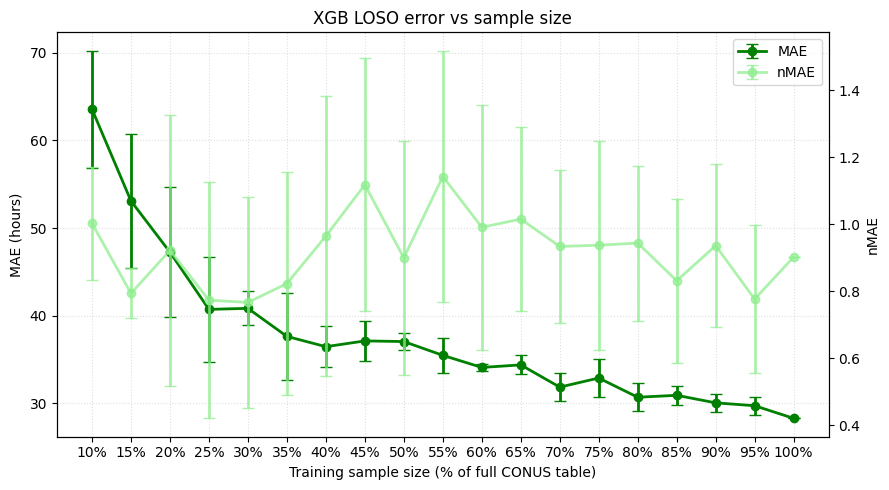

In [107]:
# --- XGB learning-curve style check: LOSO performance vs sample size ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

if "best_candidate_3" not in globals():
    raise RuntimeError("best_candidate_3 is missing. Run the XGB third-round tuning cell first.")

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

# Full CONUS modelling table
df_full = event_df.copy()
df_full["CountyFIPS"] = df_full["CountyFIPS"].astype(str).str.zfill(5)
df_full["storm"] = df_full["storm"].astype(str)

xgb_params = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "learning_rate": float(best_candidate_3["learning_rate"]),
    "n_estimators": int(best_candidate_3["n_estimators"]),
    "max_depth": int(best_candidate_3["max_depth"]),
    "min_child_weight": int(best_candidate_3["min_child_weight"]),
    "subsample": float(best_candidate_3["subsample"]),
    "colsample_bytree": float(best_candidate_3["colsample_bytree"]),
    "gamma": float(best_candidate_3["gamma"]),
    "reg_alpha": float(best_candidate_3["reg_alpha"]),
    "reg_lambda": float(best_candidate_3["reg_lambda"]),
}

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

def make_xgb_model():
    return Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBRegressor(**xgb_params)),
    ])

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

def evaluate_loso_on_subset(sub_df):
    """
    FL-style within-subset LOSO:
    - compute MAE/RMSE on each held-out storm fold
    - take the unweighted mean across folds
    - nMAE is MAE divided by the fold test-set mean t90, then averaged across folds
    """
    sub_df = sub_df.copy()
    sub_df["storm"] = sub_df["storm"].astype(str)

    groups = sub_df["storm"]
    if groups.nunique() < 2:
        return None

    X_sub = sub_df[features_v4].copy()
    y_sub = sub_df["t90"].copy()

    logo = LeaveOneGroupOut()
    fold_rows = []

    for train_idx, test_idx in logo.split(X_sub, y_sub, groups):
        X_train = X_sub.iloc[train_idx]
        X_test = X_sub.iloc[test_idx]
        y_train = y_sub.iloc[train_idx]
        y_test = y_sub.iloc[test_idx]

        model = make_xgb_model()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mae, rmse = compute_metrics(y_test, preds)
        y_test_mean = float(np.mean(y_test))
        nmae = mae / y_test_mean if y_test_mean > 0 else np.nan

        fold_rows.append({
            "MAE": mae,
            "RMSE": rmse,
            "nMAE": nmae,
        })

    fold_df = pd.DataFrame(fold_rows)

    return {
        "n_rows": len(sub_df),
        "n_storms": groups.nunique(),
        "n_folds": len(fold_df),
        "MAE_mean": fold_df["MAE"].mean(),
        "MAE_sd": fold_df["MAE"].std(ddof=0),
        "RMSE_mean": fold_df["RMSE"].mean(),
        "RMSE_sd": fold_df["RMSE"].std(ddof=0),
        "nMAE_mean": fold_df["nMAE"].mean(),
        "nMAE_sd": fold_df["nMAE"].std(ddof=0),
    }

sample_fracs = np.arange(0.1, 1.01, 0.05)
n_repeats_per_frac = 5
base_seed = 42

rows = []
rng = np.random.default_rng(base_seed)

for frac in tqdm(sample_fracs, desc="Sample-size sweep"):
    n_rows = max(2, int(round(frac * len(df_full))))
    for rep in range(n_repeats_per_frac):
        # Keep drawing until we have at least 2 storms so LOSO is defined.
        for attempt in range(100):
            seed = int(base_seed + frac * 1000 + rep * 100 + attempt)
            sub_df = df_full.sample(n=n_rows, replace=False, random_state=seed)
            if sub_df["storm"].nunique() >= 2:
                break
        else:
            raise RuntimeError(f"Could not draw a valid subset for fraction={frac:.1f}")

        summary = evaluate_loso_on_subset(sub_df)
        if summary is None:
            continue

        summary["sample_fraction"] = frac
        summary["repeat"] = rep + 1
        rows.append(summary)

curve_df = pd.DataFrame(rows)

# Aggregate across repeated subsamples for each fraction
curve_summary = (
    curve_df.groupby("sample_fraction", as_index=False)
    .agg(
        n_rows_mean=("n_rows", "mean"),
        n_storms_mean=("n_storms", "mean"),
        MAE_mean=("MAE_mean", "mean"),
        MAE_sd=("MAE_mean", "std"),
        nMAE_mean=("nMAE_mean", "mean"),
        nMAE_sd=("nMAE_mean", "std"),
        RMSE_mean=("RMSE_mean", "mean"),
        RMSE_sd=("RMSE_mean", "std"),
    )
)

print("Sample-size sweep summary:")
print(curve_summary.to_string(index=False))

print()
print("Interpretation:")
print("These are LOSO fold-mean errors on random subsamples of the full CONUS table.")
print("MAE is in hours.")
print("nMAE here is MAE divided by the fold test-set mean t90, then averaged across folds.")
print("The curve is meant to show whether error levels off as sample size increases, not a calibration interval.")

# Plot MAE and nMAE vs sample fraction
fig, ax1 = plt.subplots(figsize=(9, 5))

x = curve_summary["sample_fraction"] * 100

ax1.errorbar(
    x,
    curve_summary["MAE_mean"],
    yerr=curve_summary["MAE_sd"],
    marker="o",
    color="green",
    linewidth=2,
    capsize=4,
    label="MAE",
)
ax1.set_xlabel("Training sample size (% of full CONUS table)")
ax1.set_ylabel("MAE (hours)")
ax1.grid(True, linestyle=":", alpha=0.4)

ax2 = ax1.twinx()
ax2.errorbar(
    x,
    curve_summary["nMAE_mean"],
    yerr=curve_summary["nMAE_sd"],
    marker="o",
    color="lightgreen",
    linewidth=2,
    capsize=4,
    alpha=0.75,
    label="nMAE",
)
ax2.set_ylabel("nMAE")

ax1.set_title("XGB LOSO error vs sample size")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(v)}%" for v in x])

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.tight_layout()
plt.show()

This plot shows how LOSO MAE changes as the training sample size increases.
It is the cleanest view of the sample-size effect because MAE is on the original scale
and does not depend on any changing normalization denominator.


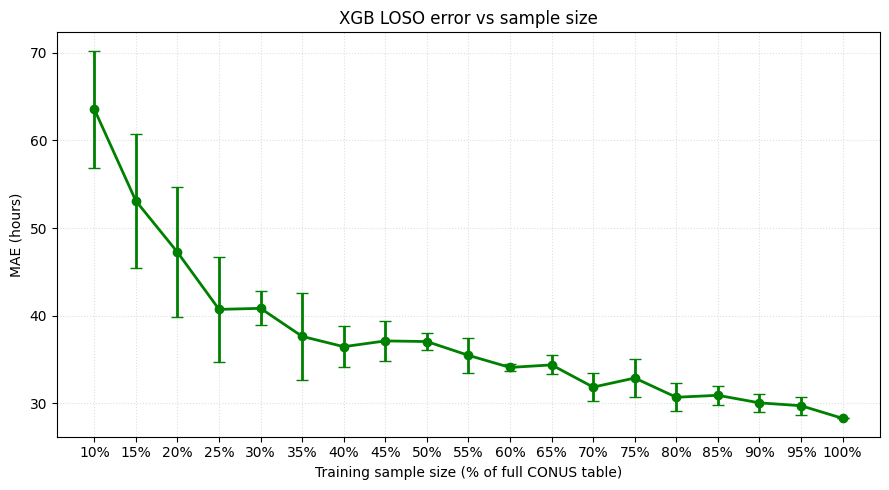


Interpretation note:
If the curve flattens, that suggests diminishing returns from adding more data.
If it keeps dropping, the model is still benefiting materially from more events.


In [108]:
# --- Sample-size sweep plot: MAE only ---

import matplotlib.pyplot as plt

if "curve_summary" not in globals():
    raise RuntimeError("curve_summary is missing. Run the sample-size sweep cell first.")

print(
    "This plot shows how LOSO MAE changes as the training sample size increases.\n"
    "It is the cleanest view of the sample-size effect because MAE is on the original scale\n"
    "and does not depend on any changing normalization denominator."
)

fig, ax = plt.subplots(figsize=(9, 5))

x = curve_summary["sample_fraction"] * 100

ax.errorbar(
    x,
    curve_summary["MAE_mean"],
    yerr=curve_summary["MAE_sd"],
    marker="o",
    color="green",
    linewidth=2,
    capsize=4,
)

ax.set_xlabel("Training sample size (% of full CONUS table)")
ax.set_ylabel("MAE (hours)")
ax.set_title("XGB LOSO error vs sample size")
ax.set_xticks(x)
ax.set_xticklabels([f"{int(v)}%" for v in x])
ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

print(
    "\nInterpretation note:\n"
    "If the curve flattens, that suggests diminishing returns from adding more data.\n"
    "If it keeps dropping, the model is still benefiting materially from more events."
)

In [106]:
# --- FL vs CONUS sample size summary ---

import pandas as pd

# Use current in-memory data if present; otherwise fall back to saved files.
if "event_df" in globals():
    conus_df = event_df.copy()
else:
    conus_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"
    conus_df = pd.read_parquet(conus_path)

if "event_FL_df" in globals():
    fl_df = event_FL_df.copy()
else:
    fl_df = conus_df[conus_df["CountyFIPS"].astype(str).str.zfill(5).str.startswith("12")].copy()

for df in (conus_df, fl_df):
    if "CountyFIPS" in df.columns:
        df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
    if "storm" in df.columns:
        df["storm"] = df["storm"].astype(str)

conus_n = len(conus_df)
fl_n = len(fl_df)

pct_of_conus = 100 * fl_n / conus_n if conus_n > 0 else float("nan")

print("Sample size comparison")
print("----------------------")
print(f"CONUS rows: {conus_n}")
print(f"Florida rows: {fl_n}")
print(f"Florida as % of CONUS: {pct_of_conus:.1f}%")

print()
print("CONUS unique counts")
print("-------------------")
if "storm" in conus_df.columns:
    print(f"Unique storms: {conus_df['storm'].nunique(dropna=True)}")
if "CountyFIPS" in conus_df.columns:
    print(f"Unique counties: {conus_df['CountyFIPS'].nunique(dropna=True)}")
if {"storm", "CountyFIPS"}.issubset(conus_df.columns):
    print(f"Unique storm × county pairs: {conus_df[['storm', 'CountyFIPS']].drop_duplicates().shape[0]}")
if "event_id" in conus_df.columns:
    print(f"Unique event_id values: {conus_df['event_id'].nunique(dropna=True)}")

print()
print("Florida unique counts")
print("---------------------")
if "storm" in fl_df.columns:
    print(f"Unique storms: {fl_df['storm'].nunique(dropna=True)}")
if "CountyFIPS" in fl_df.columns:
    print(f"Unique counties: {fl_df['CountyFIPS'].nunique(dropna=True)}")
if {"storm", "CountyFIPS"}.issubset(fl_df.columns):
    print(f"Unique storm × county pairs: {fl_df[['storm', 'CountyFIPS']].drop_duplicates().shape[0]}")
if "event_id" in fl_df.columns:
    print(f"Unique event_id values: {fl_df['event_id'].nunique(dropna=True)}")

Sample size comparison
----------------------
CONUS rows: 913
Florida rows: 90
Florida as % of CONUS: 9.9%

CONUS unique counts
-------------------
Unique storms: 28
Unique counties: 560
Unique storm × county pairs: 817
Unique event_id values: 801

Florida unique counts
---------------------
Unique storms: 7
Unique counties: 64
Unique storm × county pairs: 90
Unique event_id values: 90
